# Pilot industrial equipment extraction from PDFs

> This notebook is an experimental pilot. It does not attempt to process the entire manual. It selects 5–10 representative pages, builds manual ground truth, compares native text extraction, rules, table extraction, OCR, and LLMs, then identifies the best extraction strategy for each field before the full pipeline is built.

No value is invented: any information not visible in the document remains `None`. i-Sense fields are handled in a separate mapping layer.

## 1. Configuration

Set the PDF path and choose five to ten representative pages after an initial inspection. Page numbers are **1-based** (as in a PDF reader).

In [1]:
import os
import sys
from pathlib import Path
import json, re, random, warnings
from collections import defaultdict


PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR     = PROJECT_ROOT / 'data' / 'raw'

PDF_AUSTCOLD = DATA_DIR / 'AUSTCOLD.pdf'
PDF_MYCOM    = DATA_DIR / 'MYCOM Operating and Maintenance Manual Refrigeration Unit (1).pdf'

REPRESENTATIVE_PAGES = [
    {'page': 3, 'type': 'summary', 'description': 'Summary'},
    {'page': 9, 'type': 'section', 'description': 'Scanned/image-heavy page'},
    {'page': 18, 'type': 'safety_instructions', 'description': 'Safety instructions'},
    {'page': 28, 'type': 'maintenance_log', 'description': 'Plant history and maintenance work log'},
    {'page': 38, 'type': 'utilities_consumption_schedule', 'description': 'Utilities consumption and equipment power schedule'},
    {'page': 43, 'type': 'document_metadata', 'description': 'Document metadata and revision history'},
    {'page': 44, 'type': 'cause_effect_diagram', 'description': 'Refrigeration system cause and effect diagram'},
    {'page': 51, 'type': 'equipment_overview', 'description': 'Refrigeration system equipment overview and scope of supply'},
    {'page': 192, 'type': 'technical_data_sheet', 'description': 'Technical data sheet'},
    {'page': 189, 'type': 'drawing', 'description': 'Technical drawing'},
]

OUTPUT_DIR = Path('../results')
ENABLE_OCR = True
ENABLE_LLM = False
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Résultats : {OUTPUT_DIR.resolve()}')

Résultats : C:\Users\intel\Downloads\industrial-equipment-data-extraction\results


In [2]:
PDF_PATH = PDF_AUSTCOLD

## 2. Dependencies and PDF loading

PyMuPDF is the main component. OCR, table extraction, and LLMs are optional: an unavailable dependency is reported and the remaining experiments continue.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def optional_import(name):
    try:
        return __import__(name), None
    except ImportError as exc:
        return None, str(exc)

fitz, FITZ_ERROR = optional_import('fitz')
pytesseract, OCR_ERROR = optional_import('pytesseract')
pdfplumber, PDFPLUMBER_ERROR = optional_import('pdfplumber')
camelot, CAMELOT_ERROR = optional_import('camelot')

doc = None
if fitz is not None and PDF_PATH.exists():
    doc = fitz.open(PDF_PATH)
    print(f'PDF chargé : {PDF_PATH.name} ({doc.page_count:,} pages)')
else:
    print('Configurez PDF_PATH vers un PDF existant avant les expériences d’extraction.')

PDF chargé : AUSTCOLD.pdf (2,870 pages)


## 3. Page selection and visualisation

Examples should represent different document types. This cell displays the image, metadata, and a native-text preview without analysing the entire manual.

Page 3 | summary | Summary


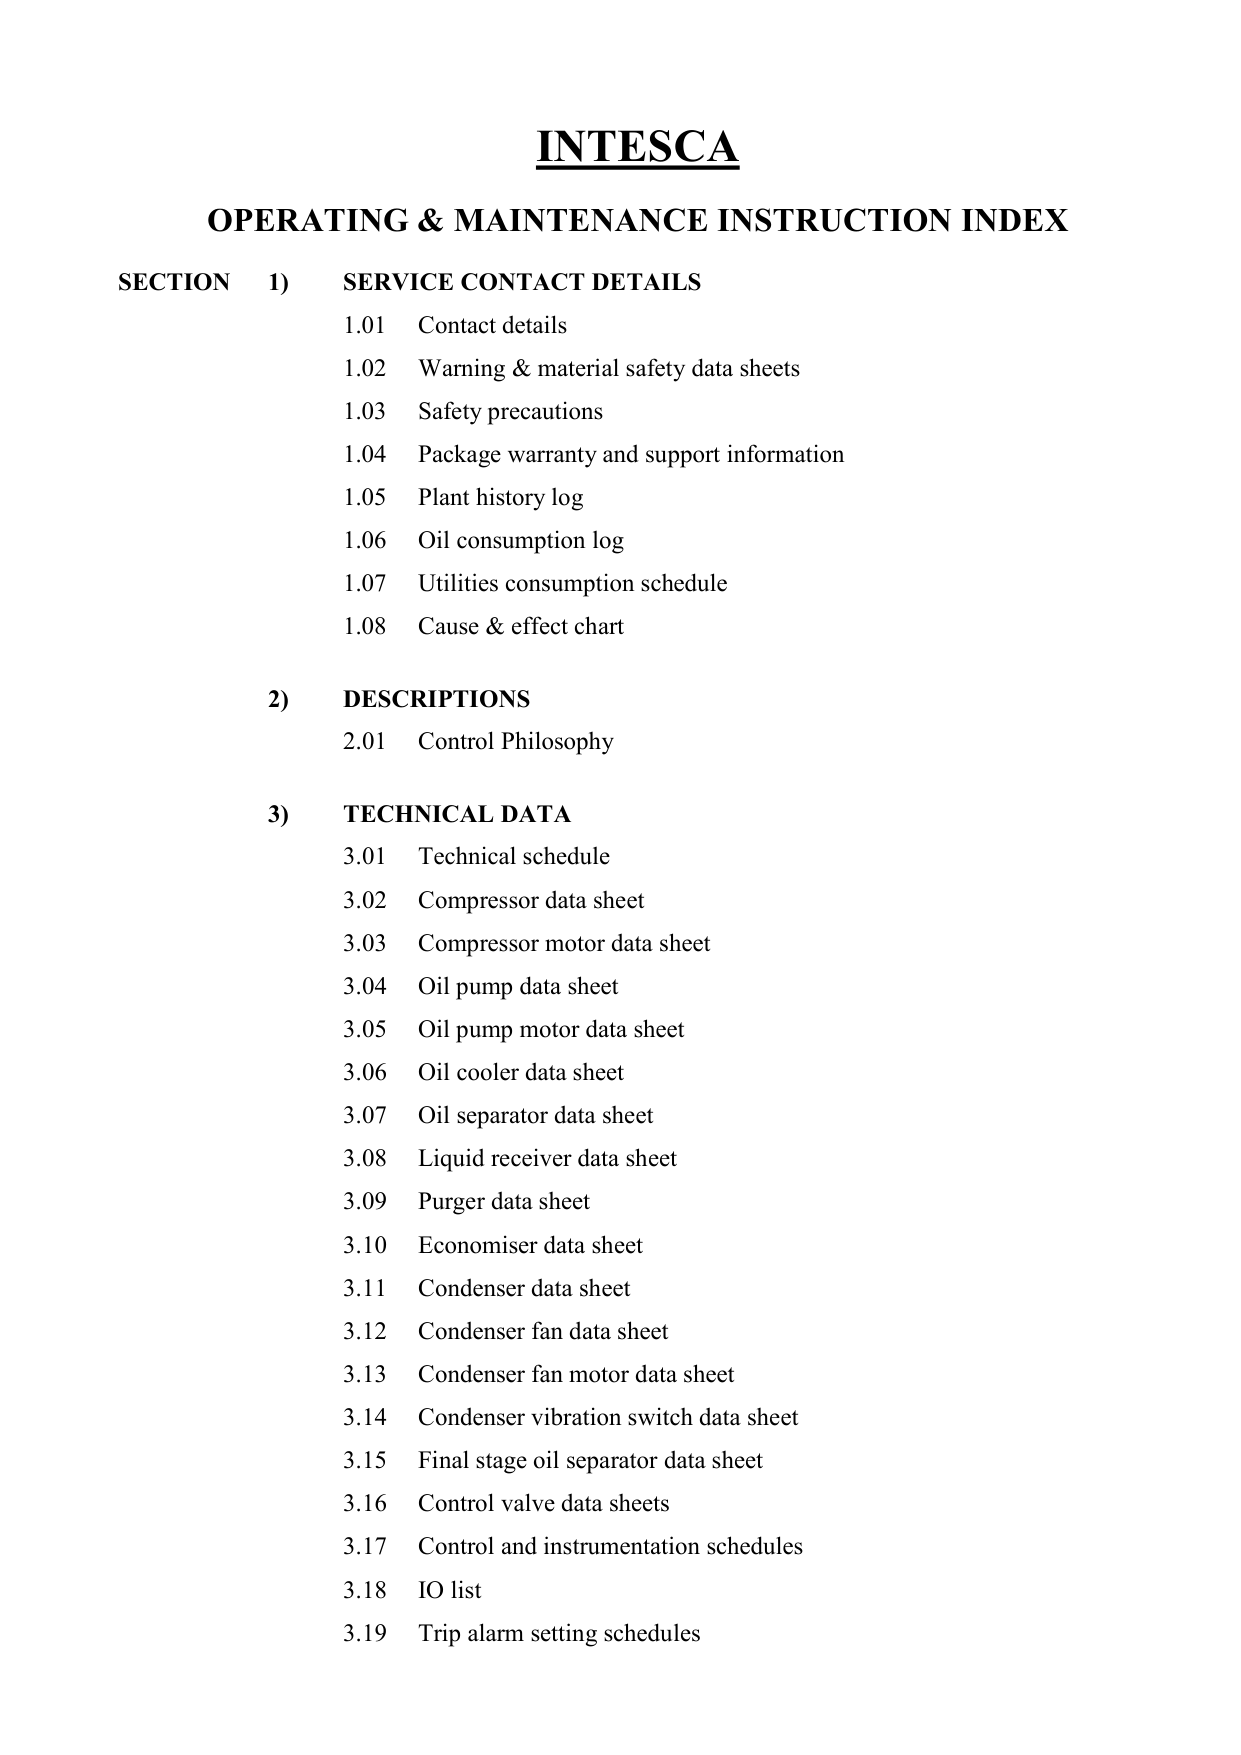

INTESCA 
 
OPERATING & MAINTENANCE INSTRUCTION INDEX 
 
SECTION 
1) 
SERVICE CONTACT DETAILS 
1.01 
Contact details 
1.02 
Warning & material safety data sheets 
1.03 
Safety precautions 
1.04 
Package warranty and support information 
1.05 
Plant history log 
1.06 
Oil consumption log 
1.07 
Utilities consumption schedule 
1.08 
Cause & effect chart 
 
 
 
2)  
DESCRIPTIONS 
2.01 
Control Philosophy 
 
 
 
3) 
TECHNICAL DATA 
3.01 
Technical schedule 
3.02 
Compressor data sheet 
3.03 
Compressor motor data sheet 
3.04 
Oil pump data sheet 
3.05 
Oil pump motor data sheet 
3.06 
Oil cooler data sheet  
3.07 
Oil separator data sheet 
3.08 
Liquid receiver data sheet 
3.09 
Purger data sheet 
3.10 
Economiser data sheet 
3.11 
Condenser data sheet 
3.12 
Condenser fan data sheet 
3.13 
Condenser fan motor data sheet 
3.14 
Condenser vibration switch data sheet 
3.15 
Final stage oil separator data sheet 
3.16 
Control valve data sheets 
3.17 
Control and instrumentation schedules 
3.18

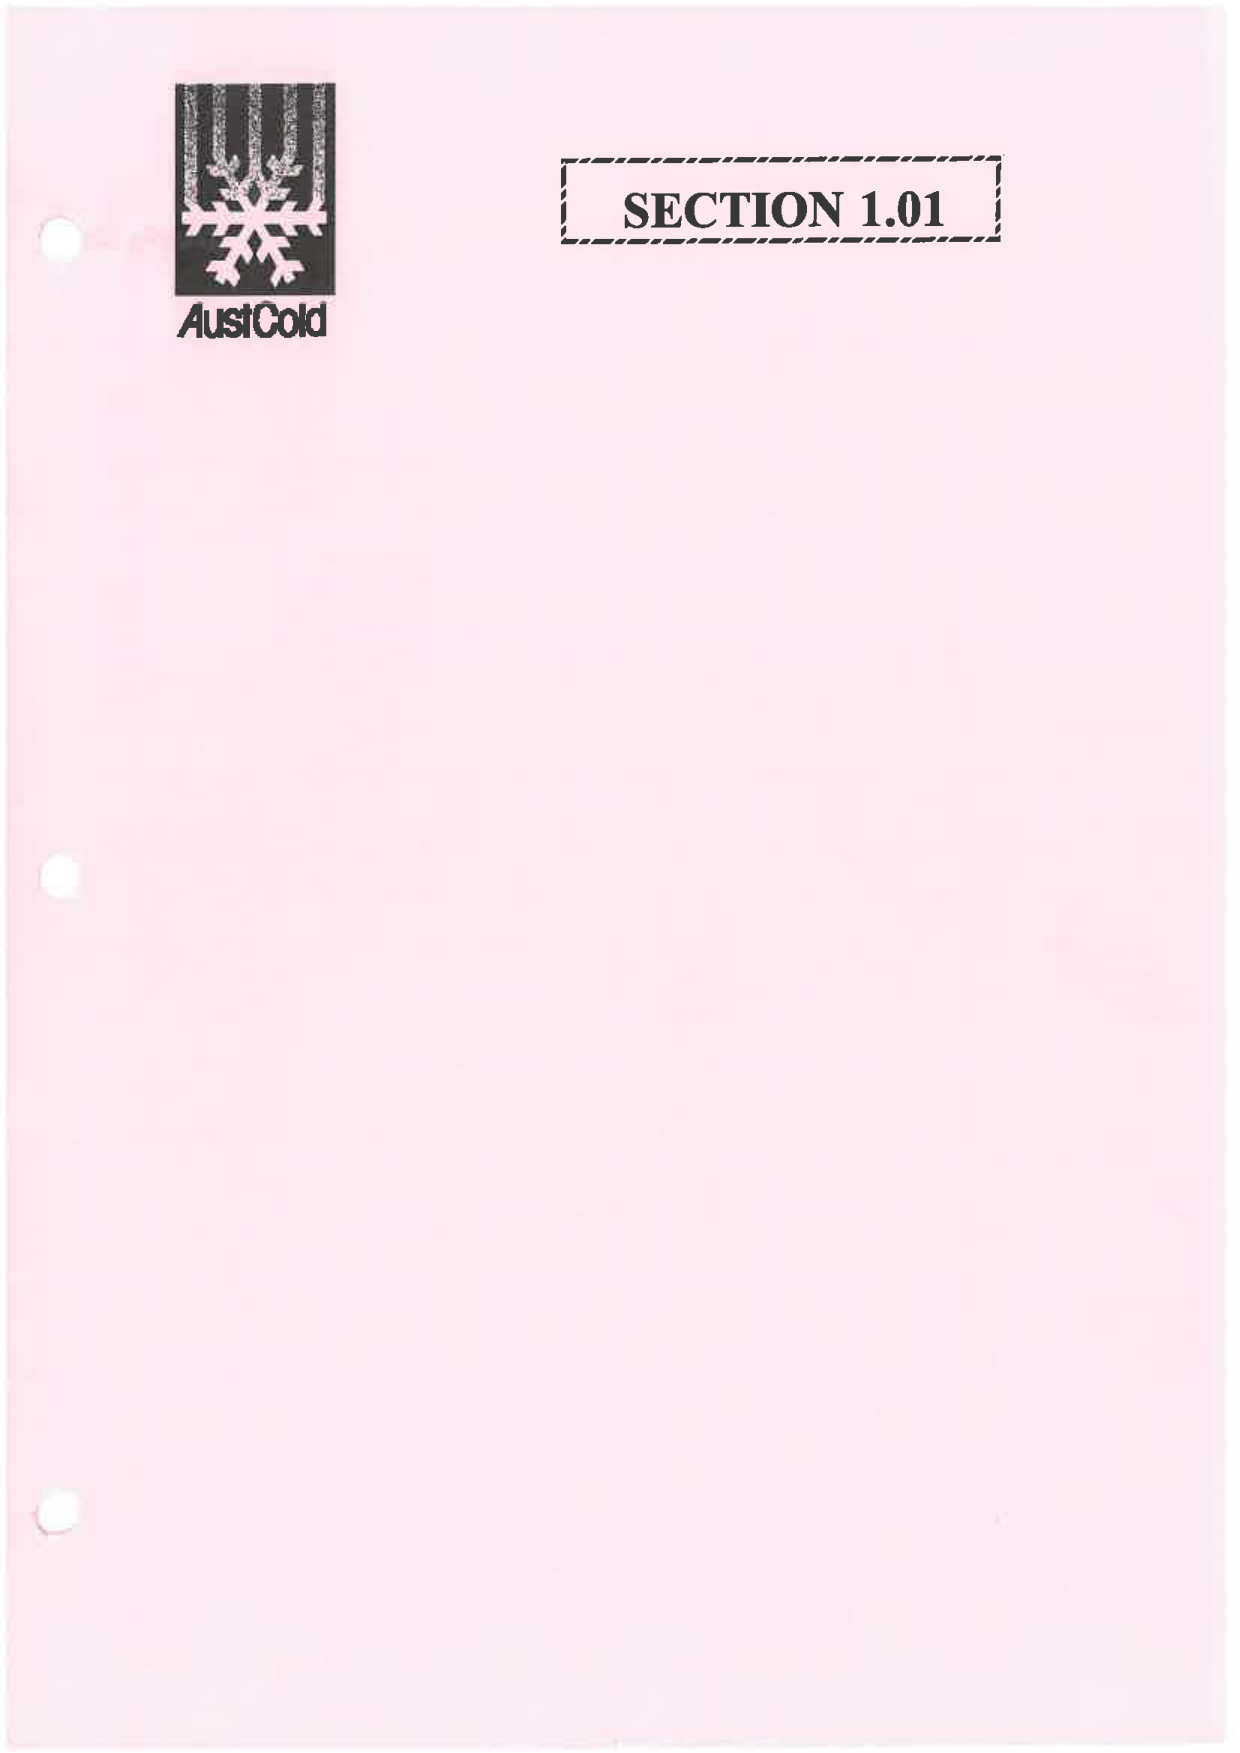

[texte natif vide]
Page 18 | safety_instructions | Safety instructions


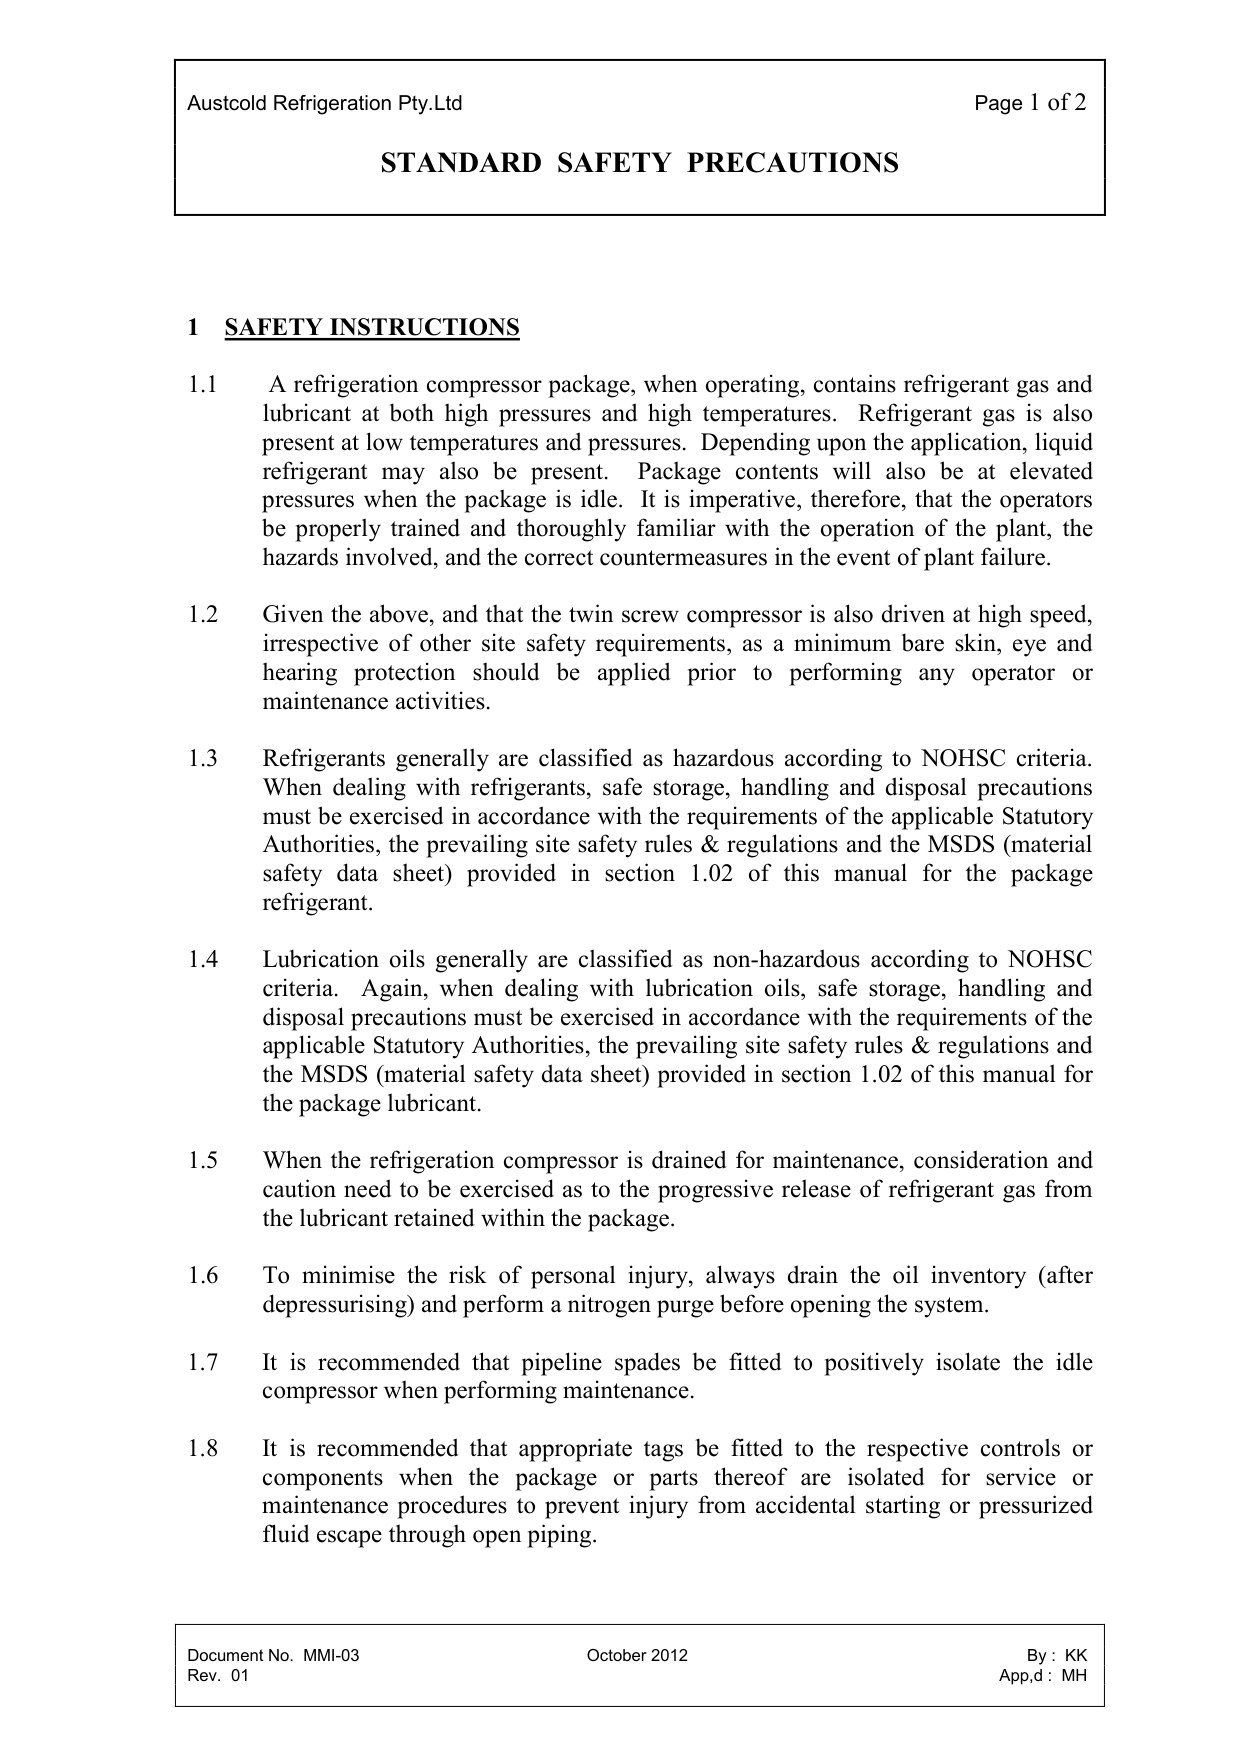

 
Austcold Refrigeration Pty.Ltd 
 
Page 1 of 2 
 
STANDARD  SAFETY  PRECAUTIONS 
 
 
Document No.  MMI-03 
October 2012 
By :  KK 
Rev.  01 
 
App,d :  MH 
 
 
1 SAFETY INSTRUCTIONS 
 
1.1 
 A refrigeration compressor package, when operating, contains refrigerant gas and 
lubricant at both high pressures and high temperatures.  Refrigerant gas is also 
present at low temperatures and pressures.  Depending upon the application, liquid 
refrigerant may also be present.  Package contents will also be at elevated 
pressures when the package is idle.  It is imperative, therefore, that the operators 
be properly trained and thoroughly familiar with the operation of the plant, the 
hazards involved, and the correct countermeasures in the event of plant failure. 
 
1.2 
Given the above, and that the twin screw compressor is also driven at high speed, 
irrespective of other site safety requirements, as a minimum bare skin, eye and 
hearing protection should be applied prior to performing any o

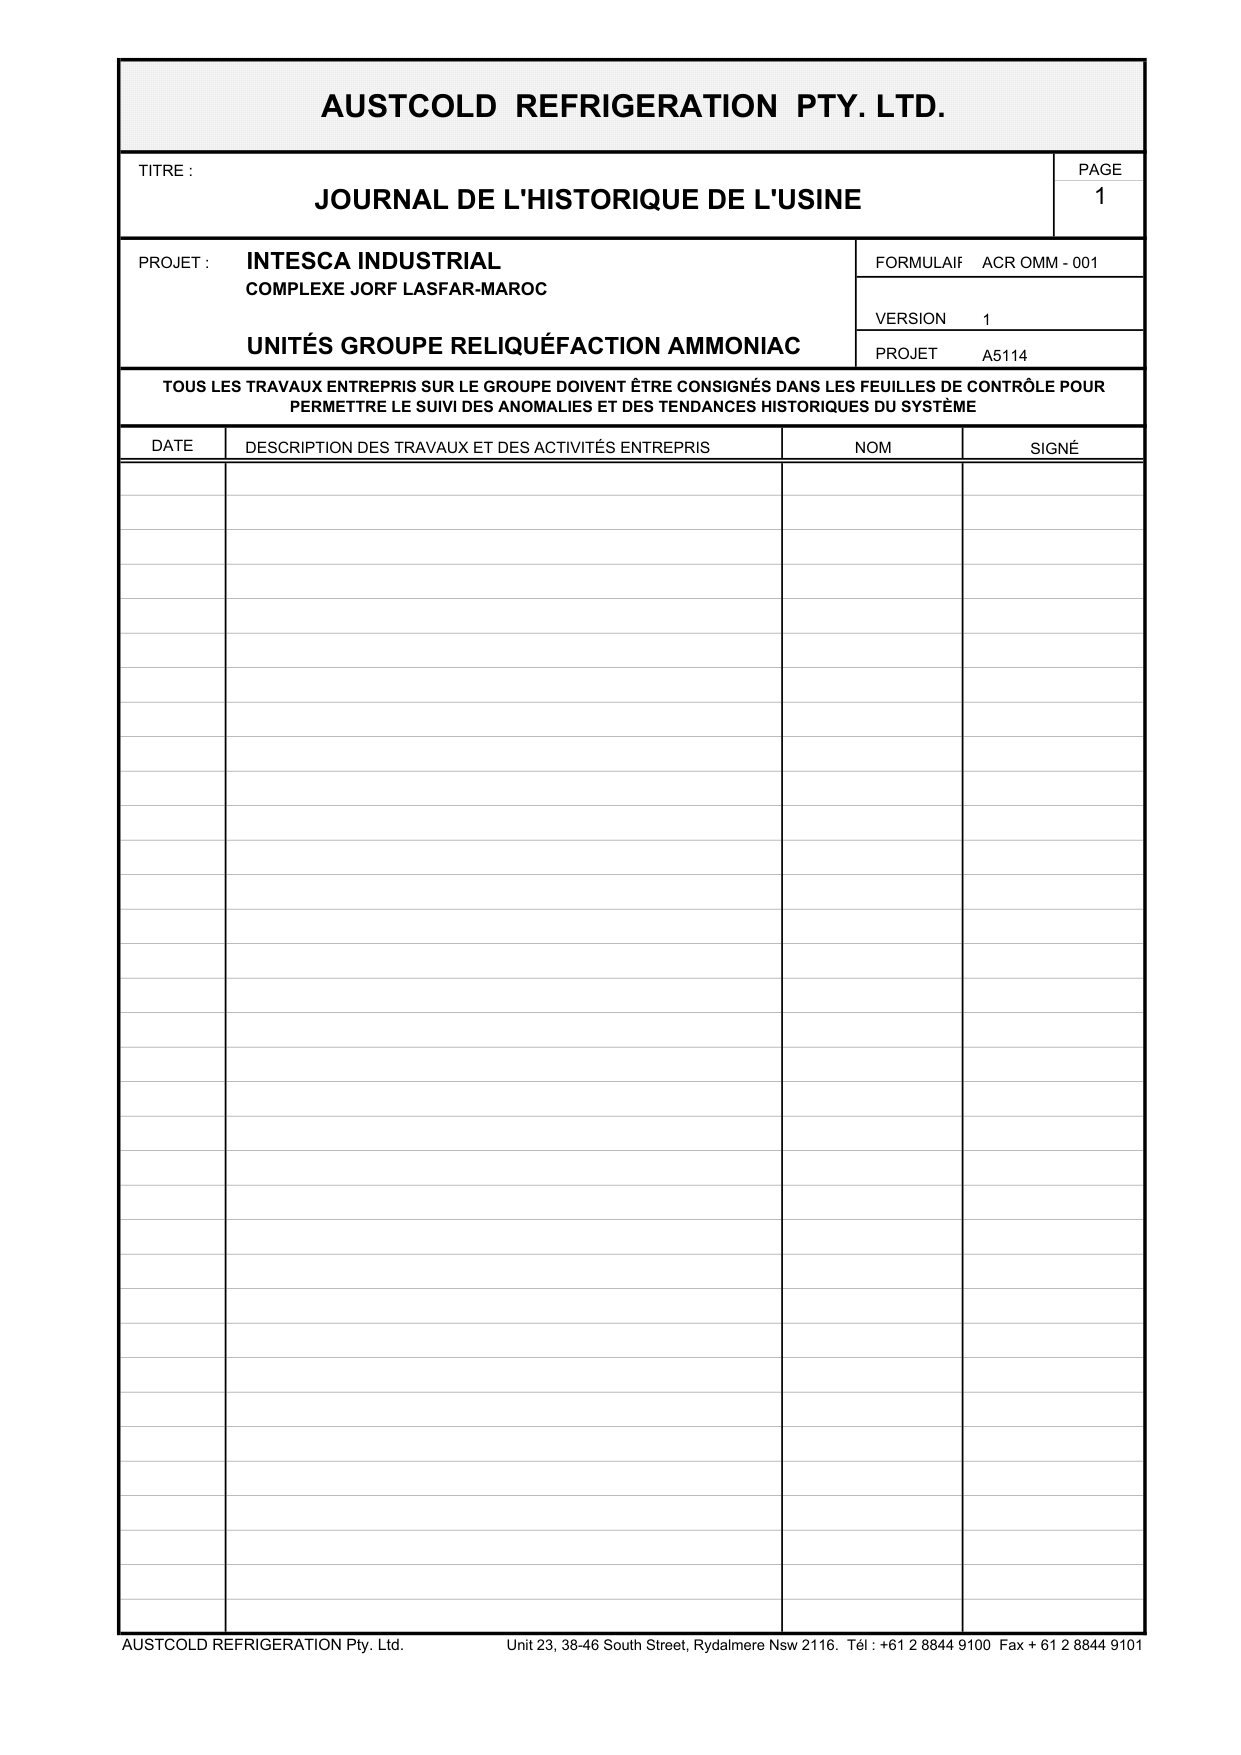

PAGE
1
PROJET :
INTESCA INDUSTRIAL
FORMULAIR
ACR OMM - 001
VERSION
UNITÉS GROUPE RELIQUÉFACTION AMMONIAC
PROJET
DATE
AUSTCOLD REFRIGERATION Pty. Ltd.
Unit 23, 38-46 South Street, Rydalmere Nsw 2116.  Tél : +61 2 8844 9100  Fax + 61 2 8844 9101
AUSTCOLD  REFRIGERATION  PTY. LTD.
TOUS LES TRAVAUX ENTREPRIS SUR LE GROUPE DOIVENT ÊTRE CONSIGNÉS DANS LES FEUILLES DE CONTRÔLE POUR 
PERMETTRE LE SUIVI DES ANOMALIES ET DES TENDANCES HISTORIQUES DU SYSTÈME
JOURNAL DE L'HISTORIQUE DE L'USINE
TITRE :
1
A5114
DESCRIPTION DES TRAVAUX ET DES ACTIVITÉS ENTREPRIS
SIGNÉ
NOM
COMPLEXE JORF LASFAR-MAROC

Page 38 | utilities_consumption_schedule | Utilities consumption and equipment power schedule


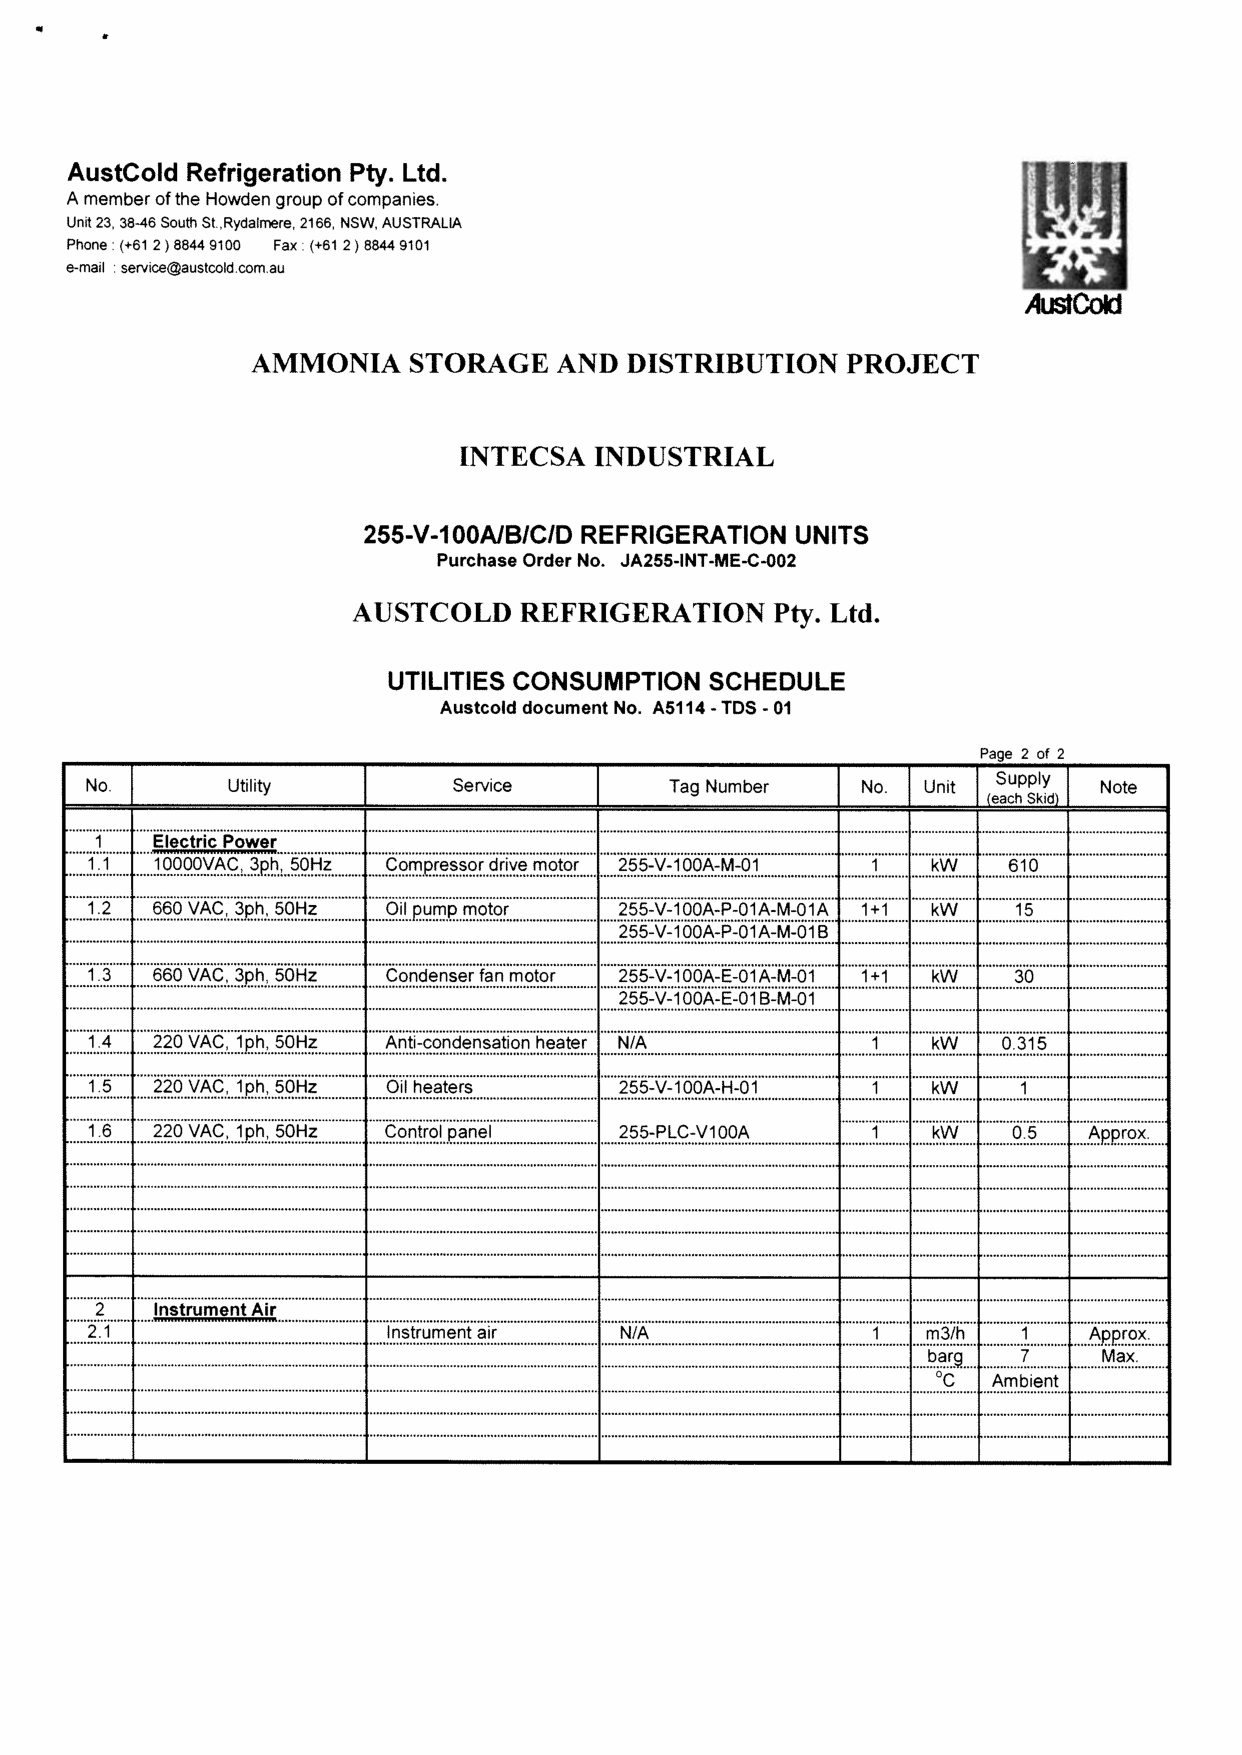

[texte natif vide]
Page 43 | document_metadata | Document metadata and revision history


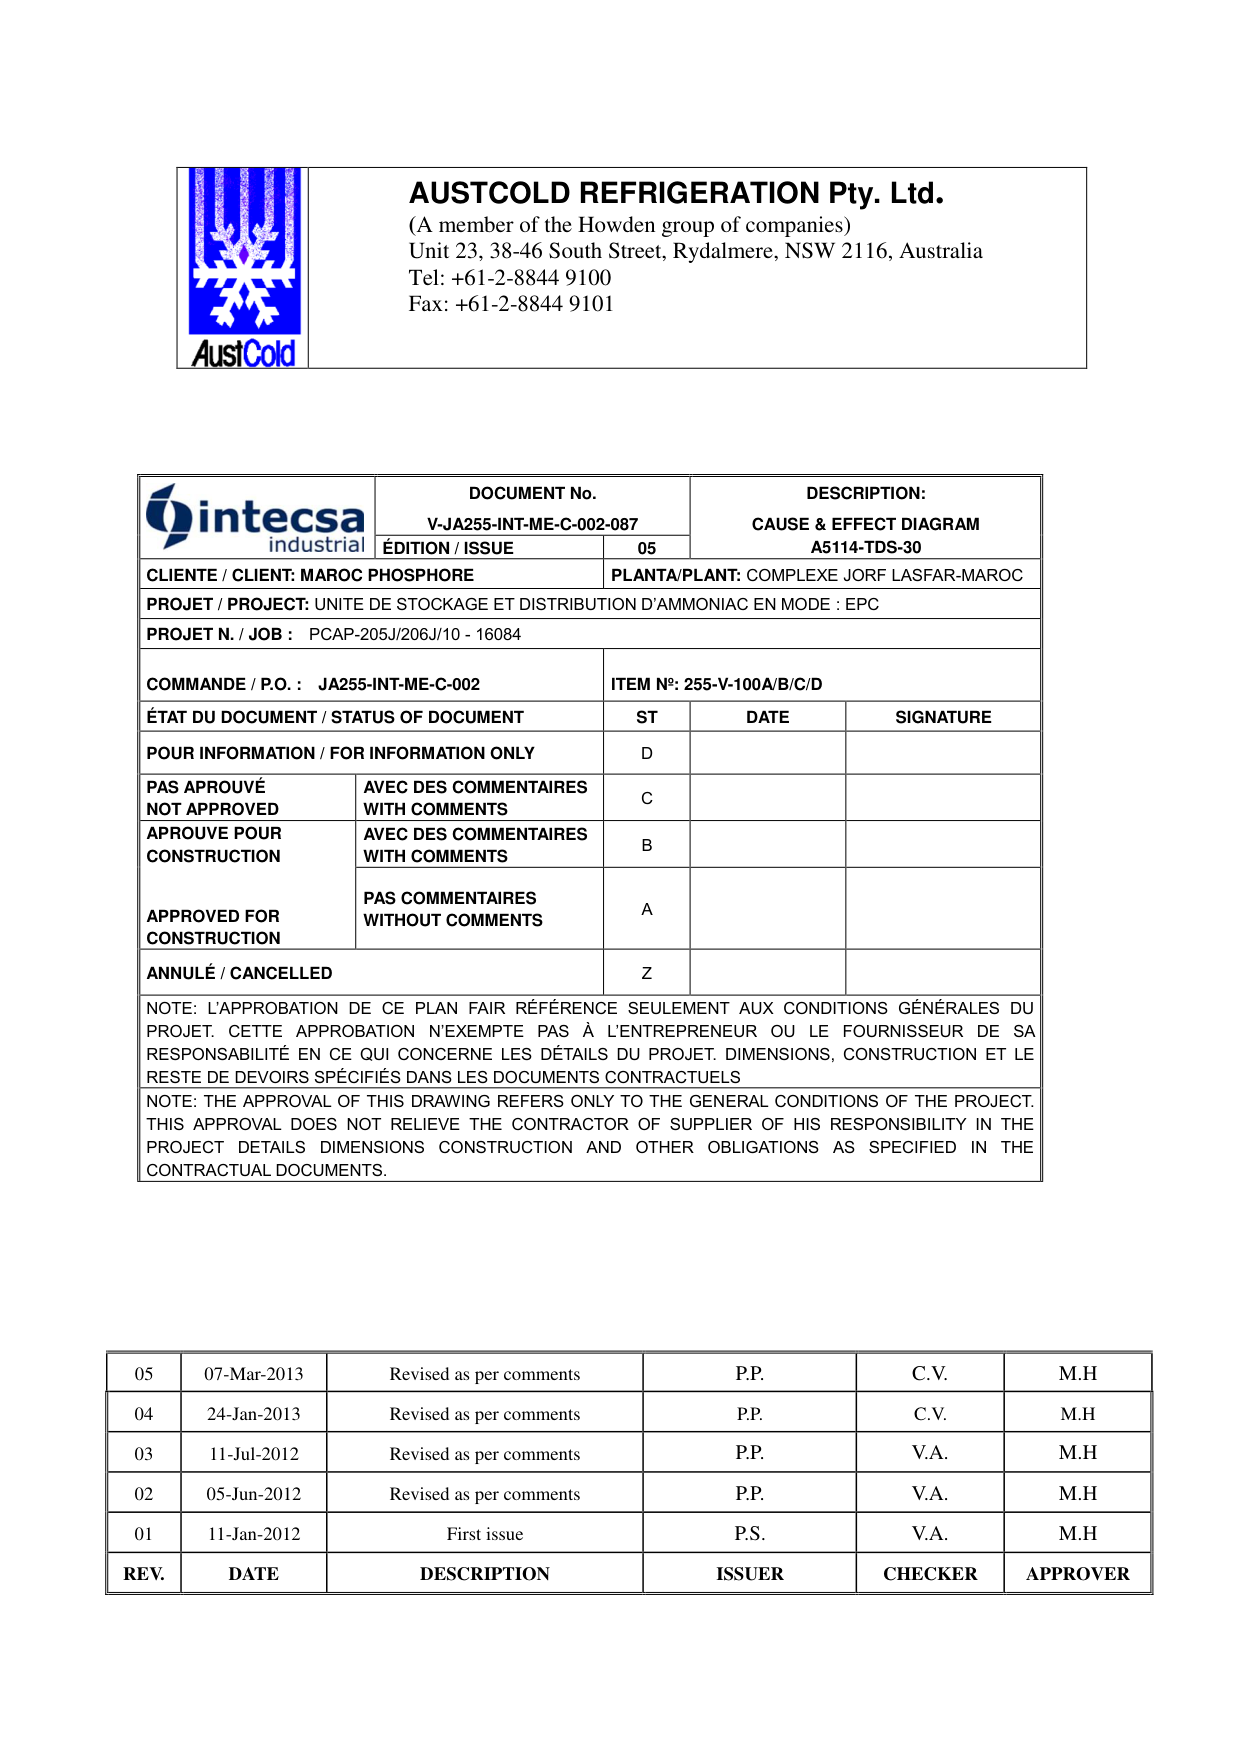

 
AUSTCOLD REFRIGERATION Pty. Ltd. 
(A member of the Howden group of companies) 
Unit 23, 38-46 South Street, Rydalmere, NSW 2116, Australia 
Tel: +61-2-8844 9100 
Fax: +61-2-8844 9101 
 
                
 
 
 
 
 
 
 
 
DOCUMENT No. 
V-JA255-INT-ME-C-002-087 
DESCRIPTION: 
CAUSE & EFFECT DIAGRAM 
A5114-TDS-30 
ÉDITION / ISSUE 
05 
CLIENTE / CLIENT: MAROC PHOSPHORE 
PLANTA/PLANT: COMPLEXE JORF LASFAR-MAROC 
PROJET / PROJECT: UNITE DE STOCKAGE ET DISTRIBUTION D’AMMONIAC EN MODE : EPC 
PROJET N. / JOB :  PCAP-205J/206J/10 - 16084 
COMMANDE / P.O. :  JA255-INT-ME-C-002 
ITEM Nº: 255-V-100A/B/C/D 
ÉTAT DU DOCUMENT / STATUS OF DOCUMENT 
ST 
DATE 
SIGNATURE 
POUR INFORMATION / FOR INFORMATION ONLY 
D 
 
 
PAS APROUVÉ 
NOT APPROVED 
AVEC DES COMMENTAIRES 
WITH COMMENTS 
C 
 
 
APROUVE POUR 
CONSTRUCTION 
 
APPROVED FOR 
CONSTRUCTION 
AVEC DES COMMENTAIRES 
WITH COMMENTS 
B 
 
 
PAS COMMENTAIRES 
WITHOUT COMMENTS 
A 
 
 
ANNULÉ / CANCELLED 
Z 
 
 
NOTE: L’APPROBATION DE CE PLAN FAIR RÉFÉRENCE 

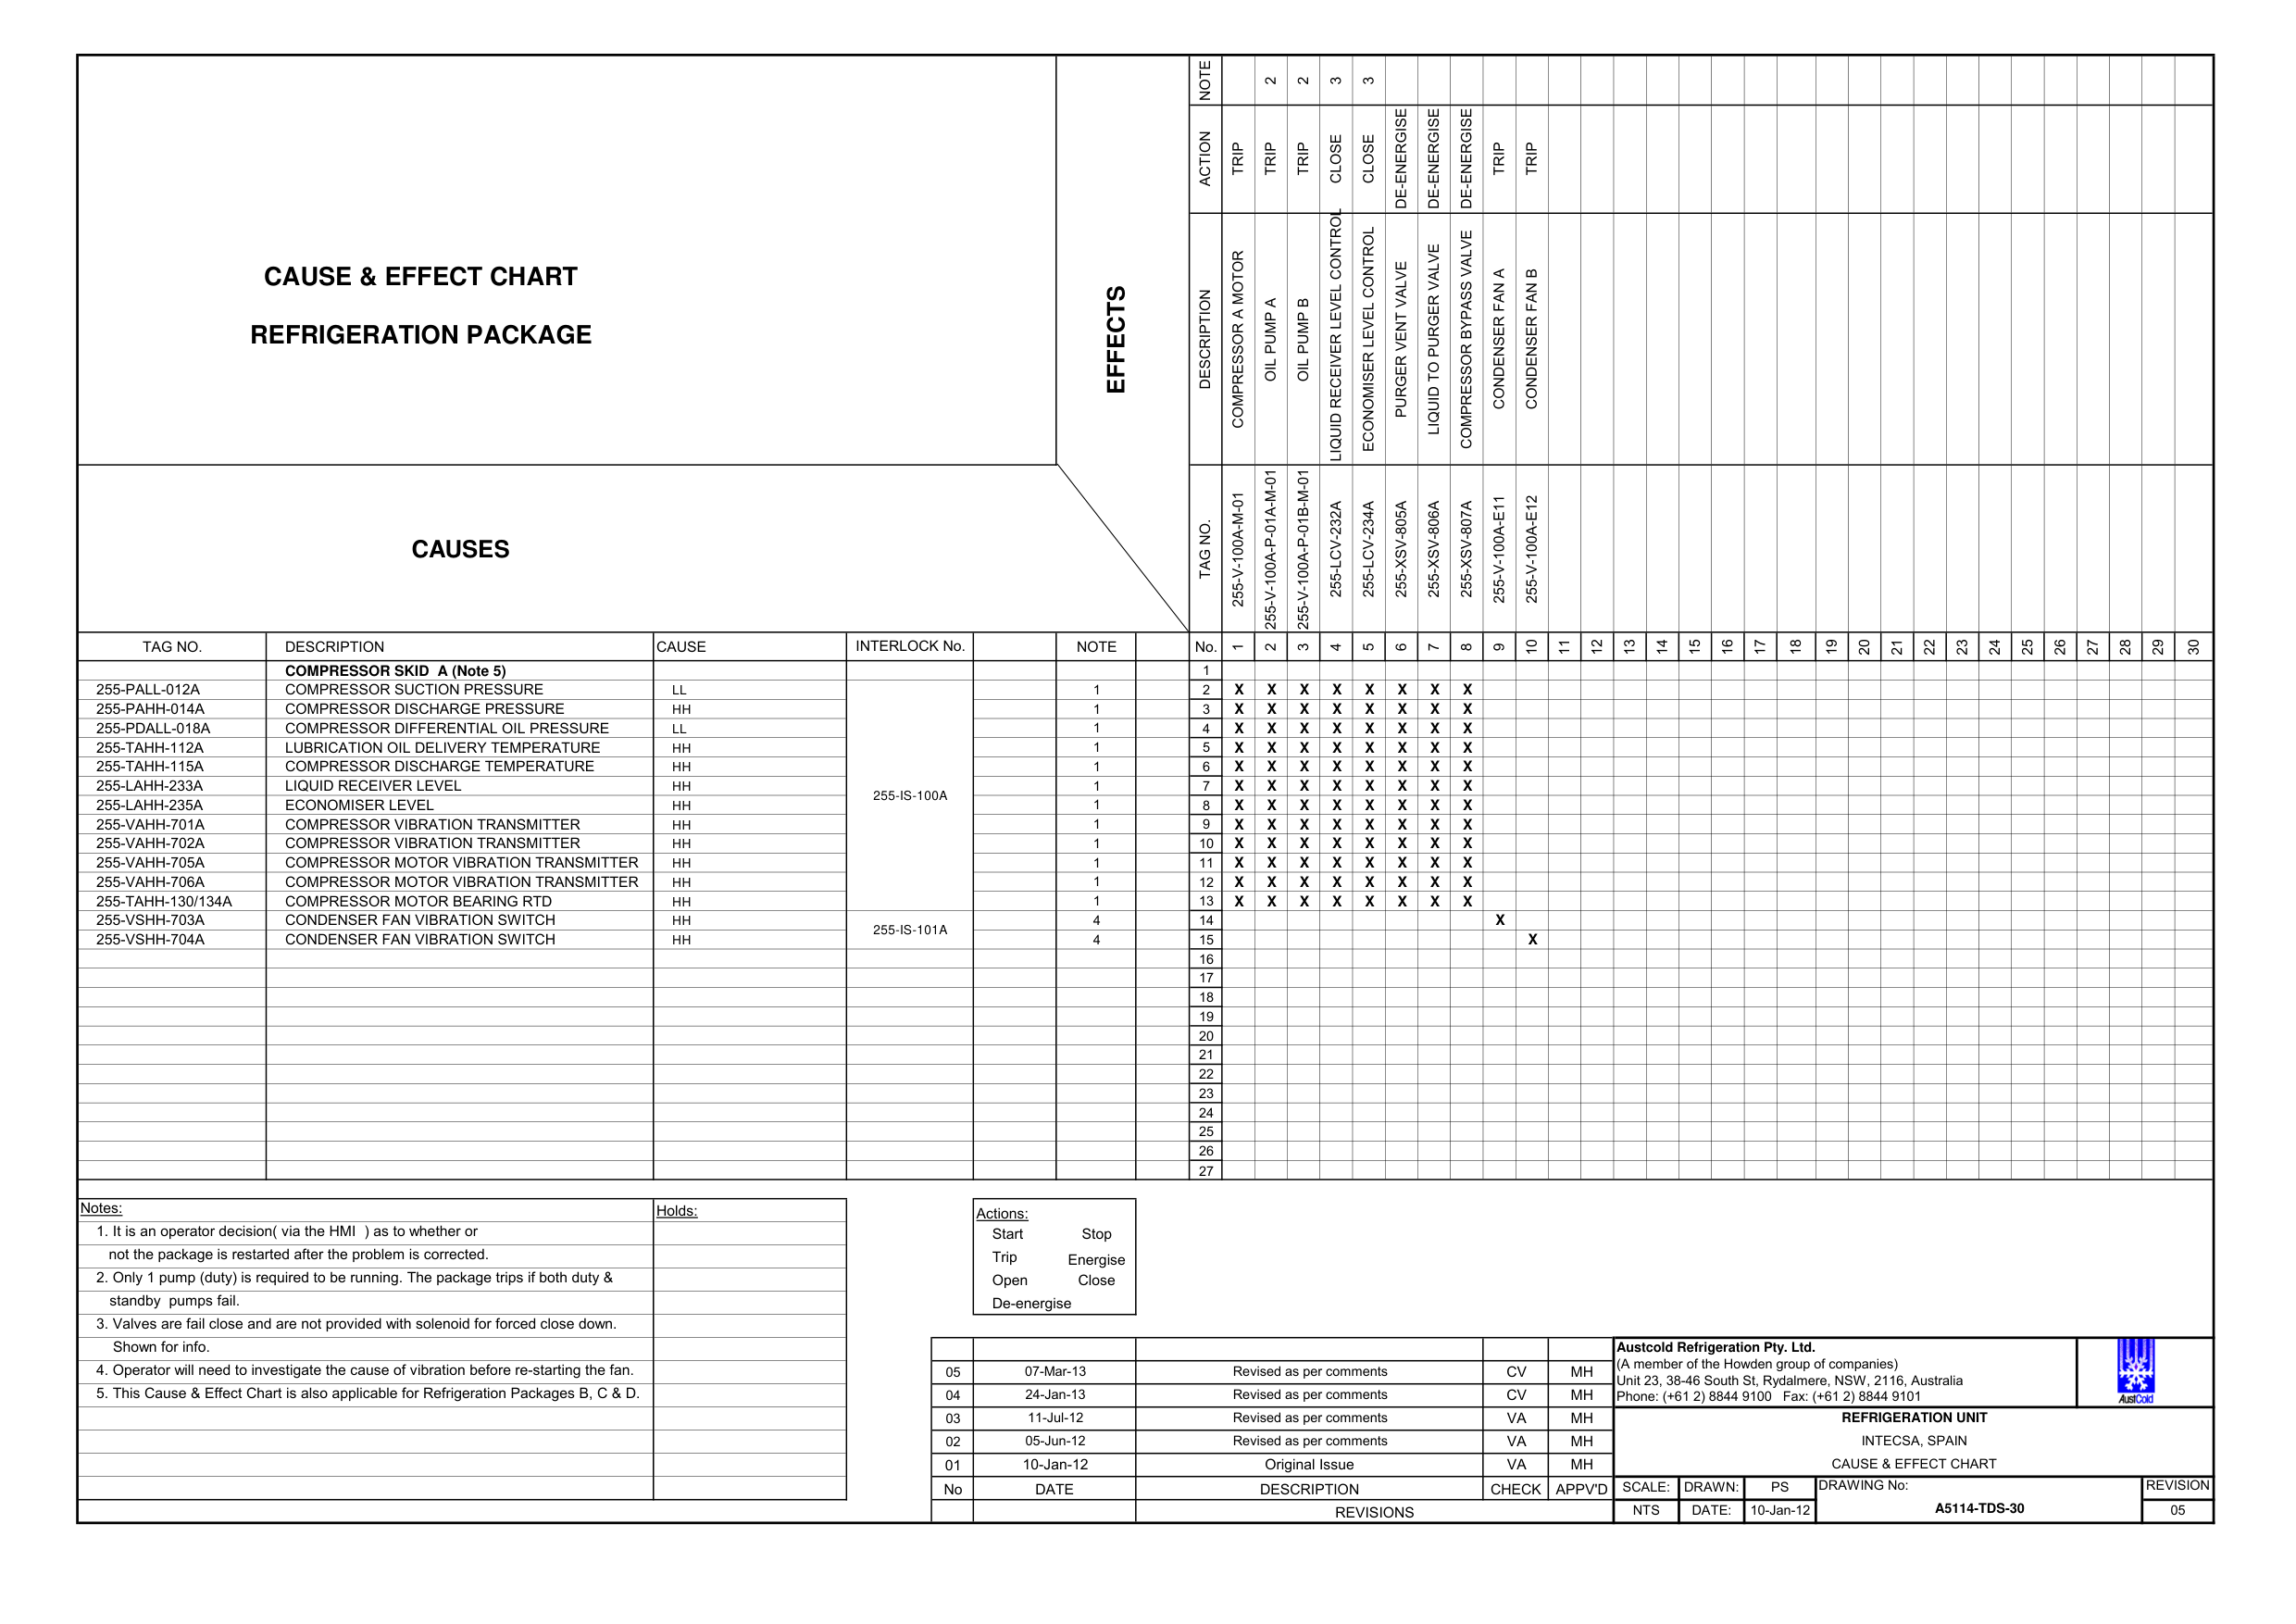

NOTE
2
2
3
3
 
EFFECTS
DESCRIPTION
COMPRESSOR A MOTOR
OIL PUMP A
OIL PUMP B
LIQUID RECEIVER LEVEL CONTROL
ECONOMISER LEVEL CONTROL
PURGER VENT VALVE
LIQUID TO PURGER VALVE
COMPRESSOR BYPASS VALVE
CONDENSER FAN A
CONDENSER FAN B
CAUSES
TAG NO.
255-V-100A-M-01
255-V-100A-P-01A-M-01
255-V-100A-P-01B-M-01
255-LCV-232A
255-LCV-234A
255-XSV-805A
255-XSV-806A
255-XSV-807A
255-V-100A-E11
255-V-100A-E12
TAG NO.
DESCRIPTION
CAUSE
NOTE
No.
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
COMPRESSOR SKID  A (Note 5)
1
255-PALL-012A
COMPRESSOR SUCTION PRESSURE
LL
1
2
X
X
X
X
X
X
X
X
255-PAHH-014A
COMPRESSOR DISCHARGE PRESSURE
HH
1
3
X
X
X
X
X
X
X
X
255-PDALL-018A
COMPRESSOR DIFFERENTIAL OIL PRESSURE
LL
1
4
X
X
X
X
X
X
X
X
255-TAHH-112A
LUBRICATION OIL DELIVERY TEMPERATURE
HH
1
5
X
X
X
X
X
X
X
X
255-TAHH-115A
COMPRESSOR DISCHARGE TEMPERATURE
HH
1
6
X
X
X
X
X
X
X
X
255-LAHH-233A
LIQUID RECEIVER LEVEL
HH
1
7
X
X
X
X
X
X
X
X
255-LAHH-235A
ECONOMISER LEVEL
HH
1
8
X
X
X
X


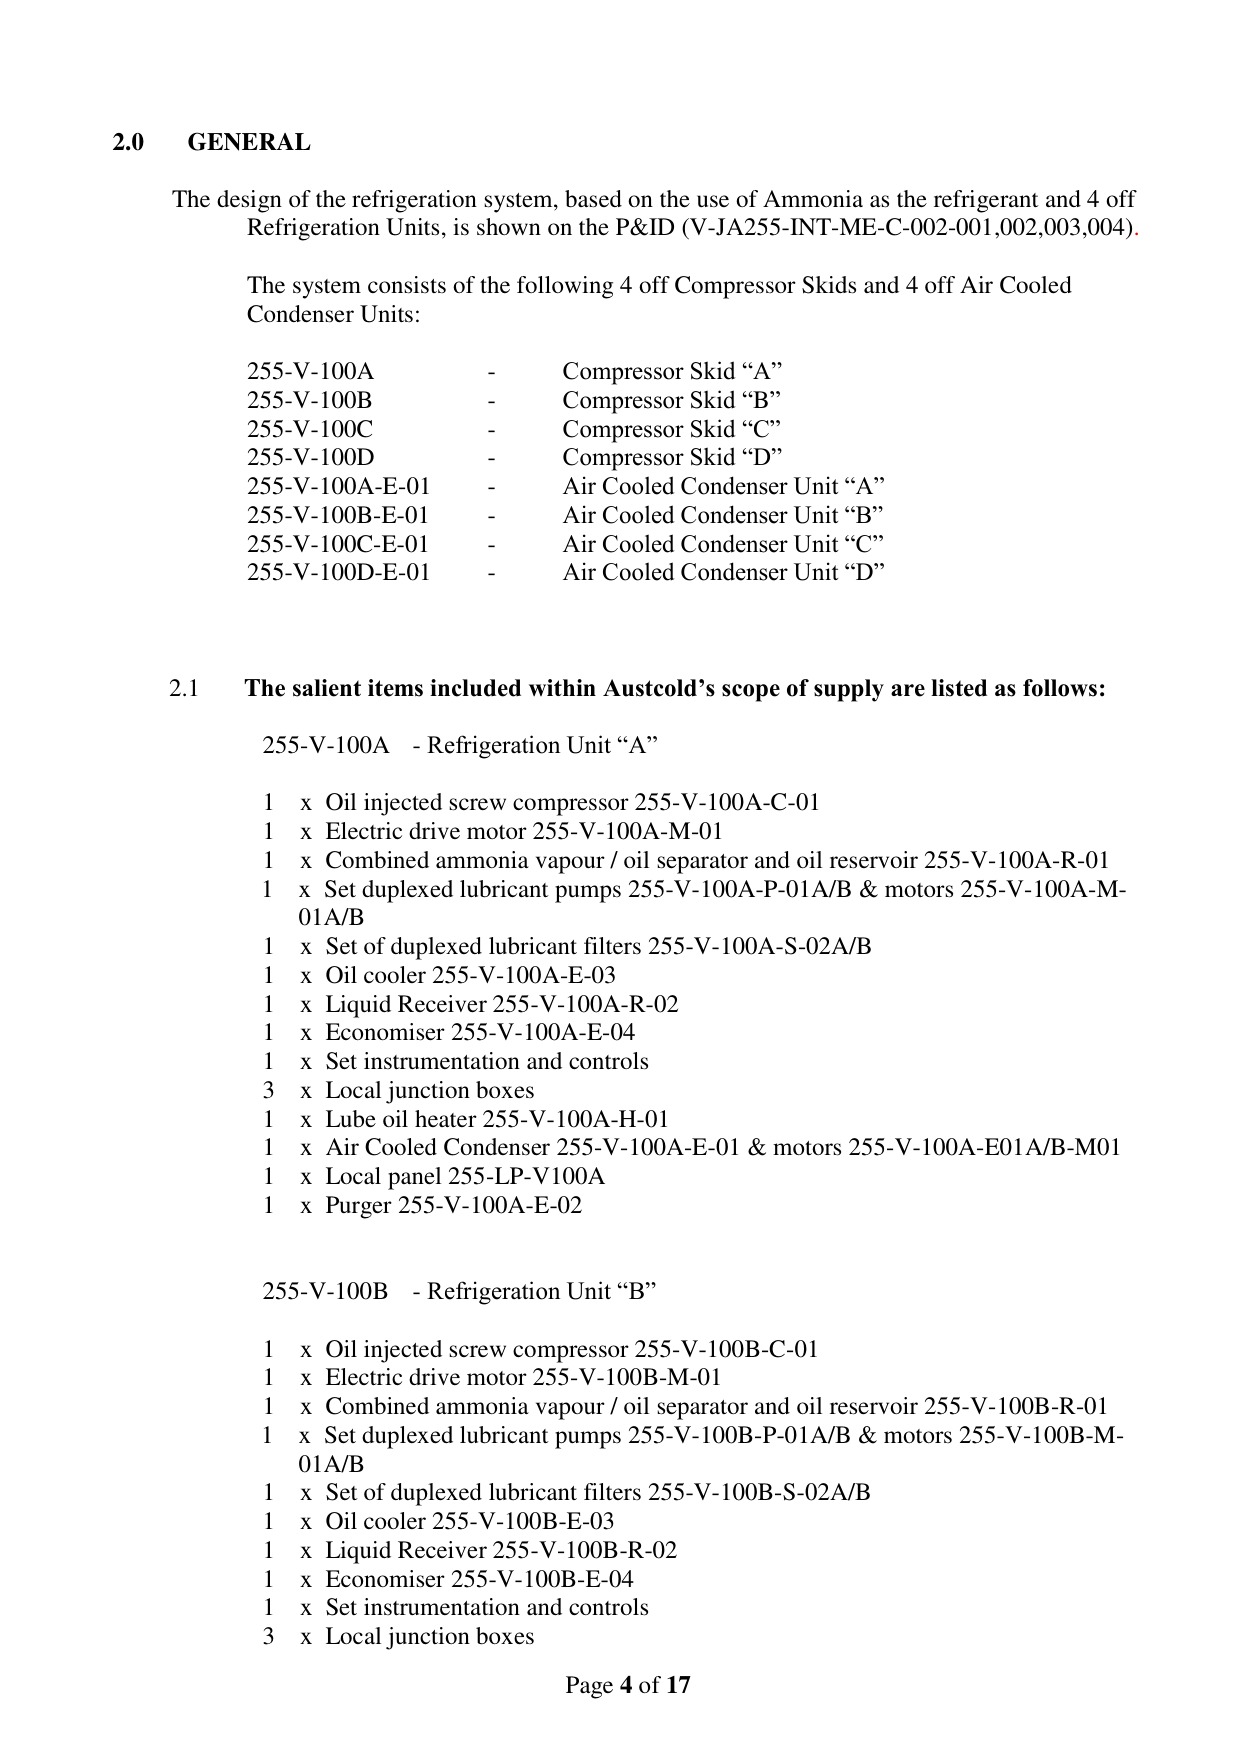

 
Page 4 of 17 
 
 
2.0 
GENERAL 
 
The design of the refrigeration system, based on the use of Ammonia as the refrigerant and 4 off 
Refrigeration Units, is shown on the P&ID (V-JA255-INT-ME-C-002-001,002,003,004).  
 
The system consists of the following 4 off Compressor Skids and 4 off Air Cooled 
Condenser Units:  
 
255-V-100A 
 
- 
Compressor Skid “A” 
255-V-100B 
 
- 
Compressor Skid “B” 
255-V-100C 
 
- 
Compressor Skid “C” 
255-V-100D 
 
- 
Compressor Skid “D” 
255-V-100A-E-01 
- 
Air Cooled Condenser Unit “A” 
255-V-100B-E-01 
- 
Air Cooled Condenser Unit “B” 
255-V-100C-E-01 
- 
Air Cooled Condenser Unit “C” 
255-V-100D-E-01 
- 
Air Cooled Condenser Unit “D” 
 
 
 
2.1 
The salient items included within Austcold’s scope of supply are listed as follows: 
 
 255-V-100A - Refrigeration Unit “A” 
 
1 x  Oil injected screw compressor 255-V-100A-C-01                                        
1 x  Electric drive motor 255-V-100A-M-01                                        
1 x  Combi

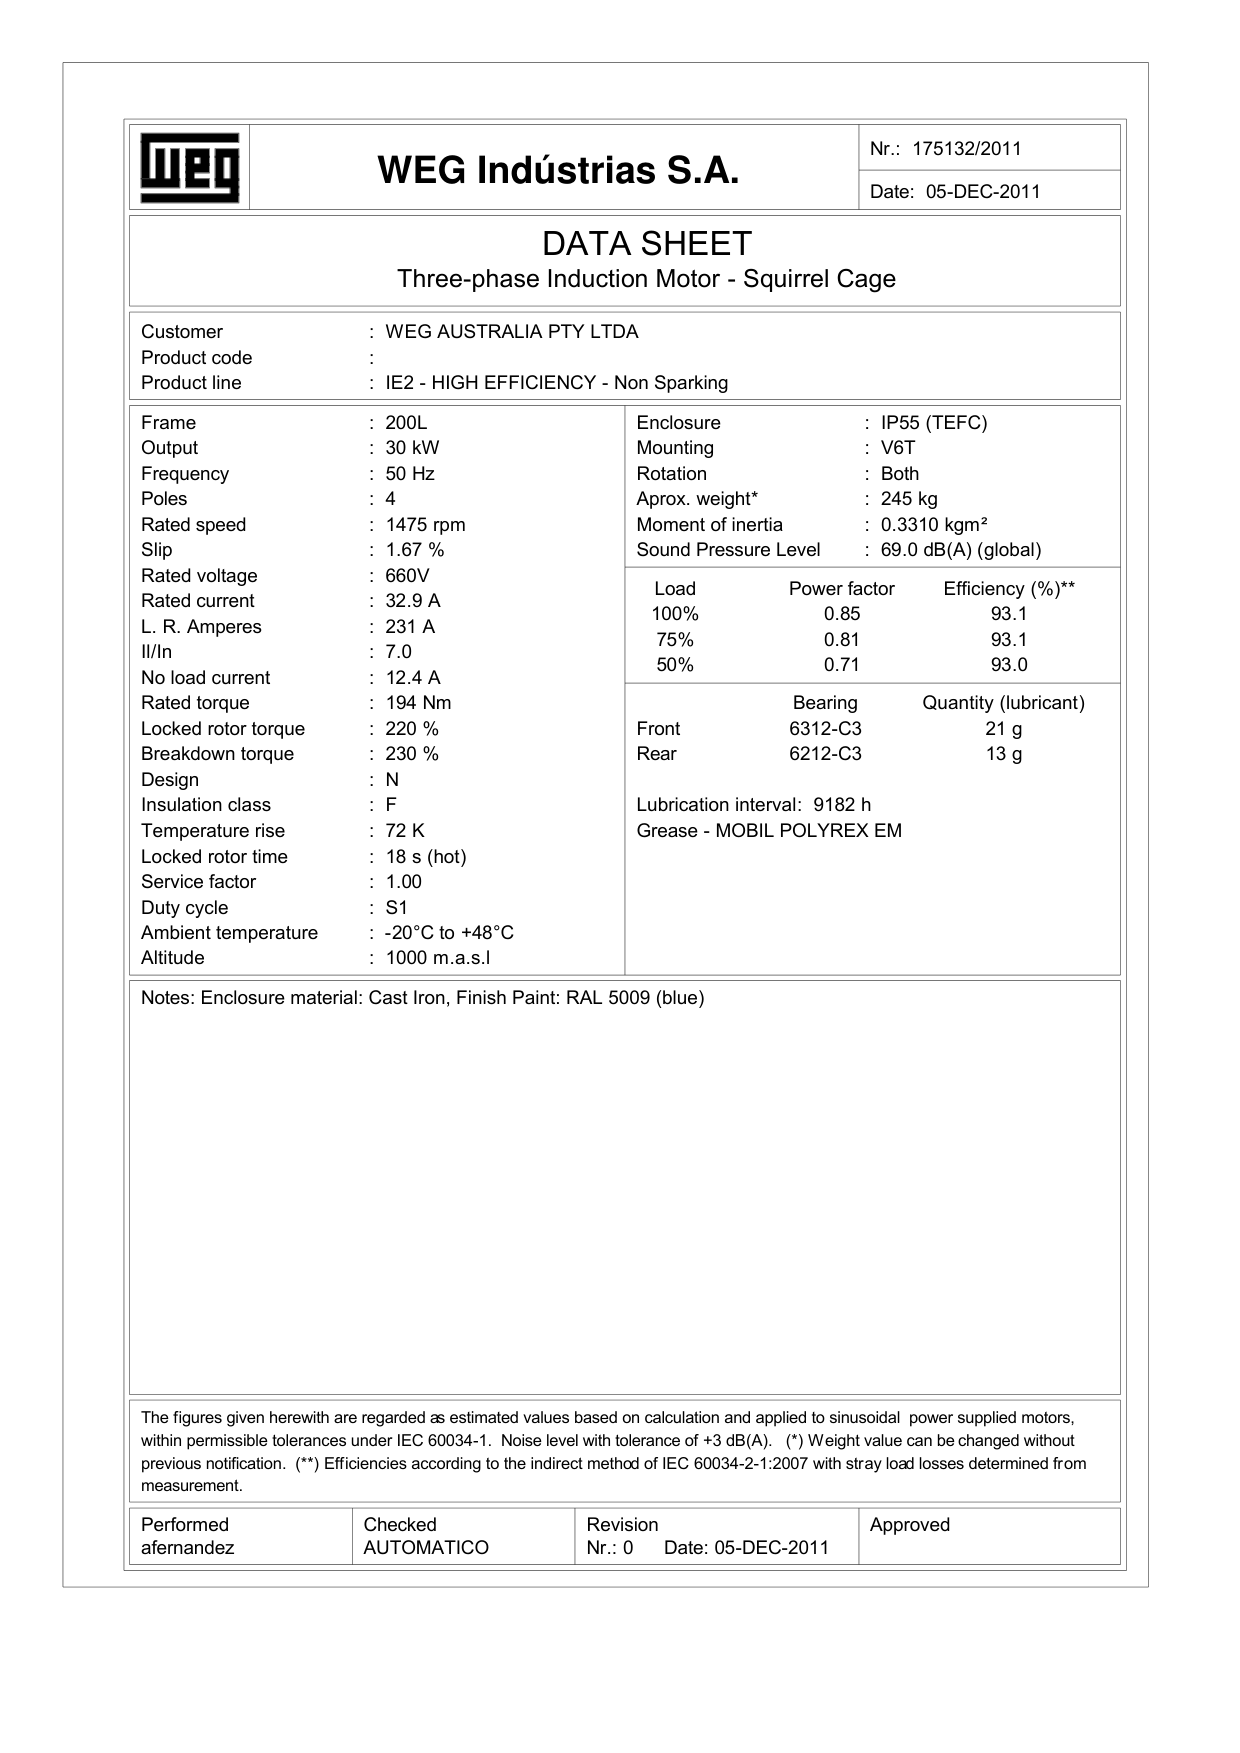

WEG Indústrias S.A.
Nr.:  175132/2011
Date:  05-DEC-2011
DATA SHEET
Three-phase Induction Motor - Squirrel Cage
Customer
:  WEG AUSTRALIA PTY LTDA
Product code
:  
Product line
:  IE2 - HIGH EFFICIENCY - Non Sparking
Frame
:  200L
Output
:  30 kW
Frequency
:  50 Hz
Poles
:  4
Rated speed
:  1475 rpm
Slip
:  1.67 %
Rated voltage
:  660V
Rated current
:  32.9 A
L. R. Amperes
:  231 A
Il/In
:  7.0
No load current
:  12.4 A
Rated torque
:  194 Nm
Locked rotor torque
:  220 %
Breakdown torque
:  230 %
Design
:  N
Insulation class
:  F
Temperature rise
:  72 K
Locked rotor time
:  18 s (hot)
Service factor
:  1.00
Duty cycle
:  S1
Ambient temperature
:  -20°C to +48°C
Altitude
:  1000 m.a.s.l
Enclosure
:  IP55 (TEFC)
Mounting
:  V6T
Rotation
:  Both
Aprox. weight*
:  245 kg
Moment of inertia
:  0.3310 kgm²
Sound Pressure Level
:  69.0 dB(A) (global)
Load
Power factor
Efficiency (%)**
100%
0.85
93.1
75%
0.81
93.1
50%
0.71
93.0
Bearing
Quantity (lubricant)
Front
6312-C3
21 g
Rear
6212-C3
13 g


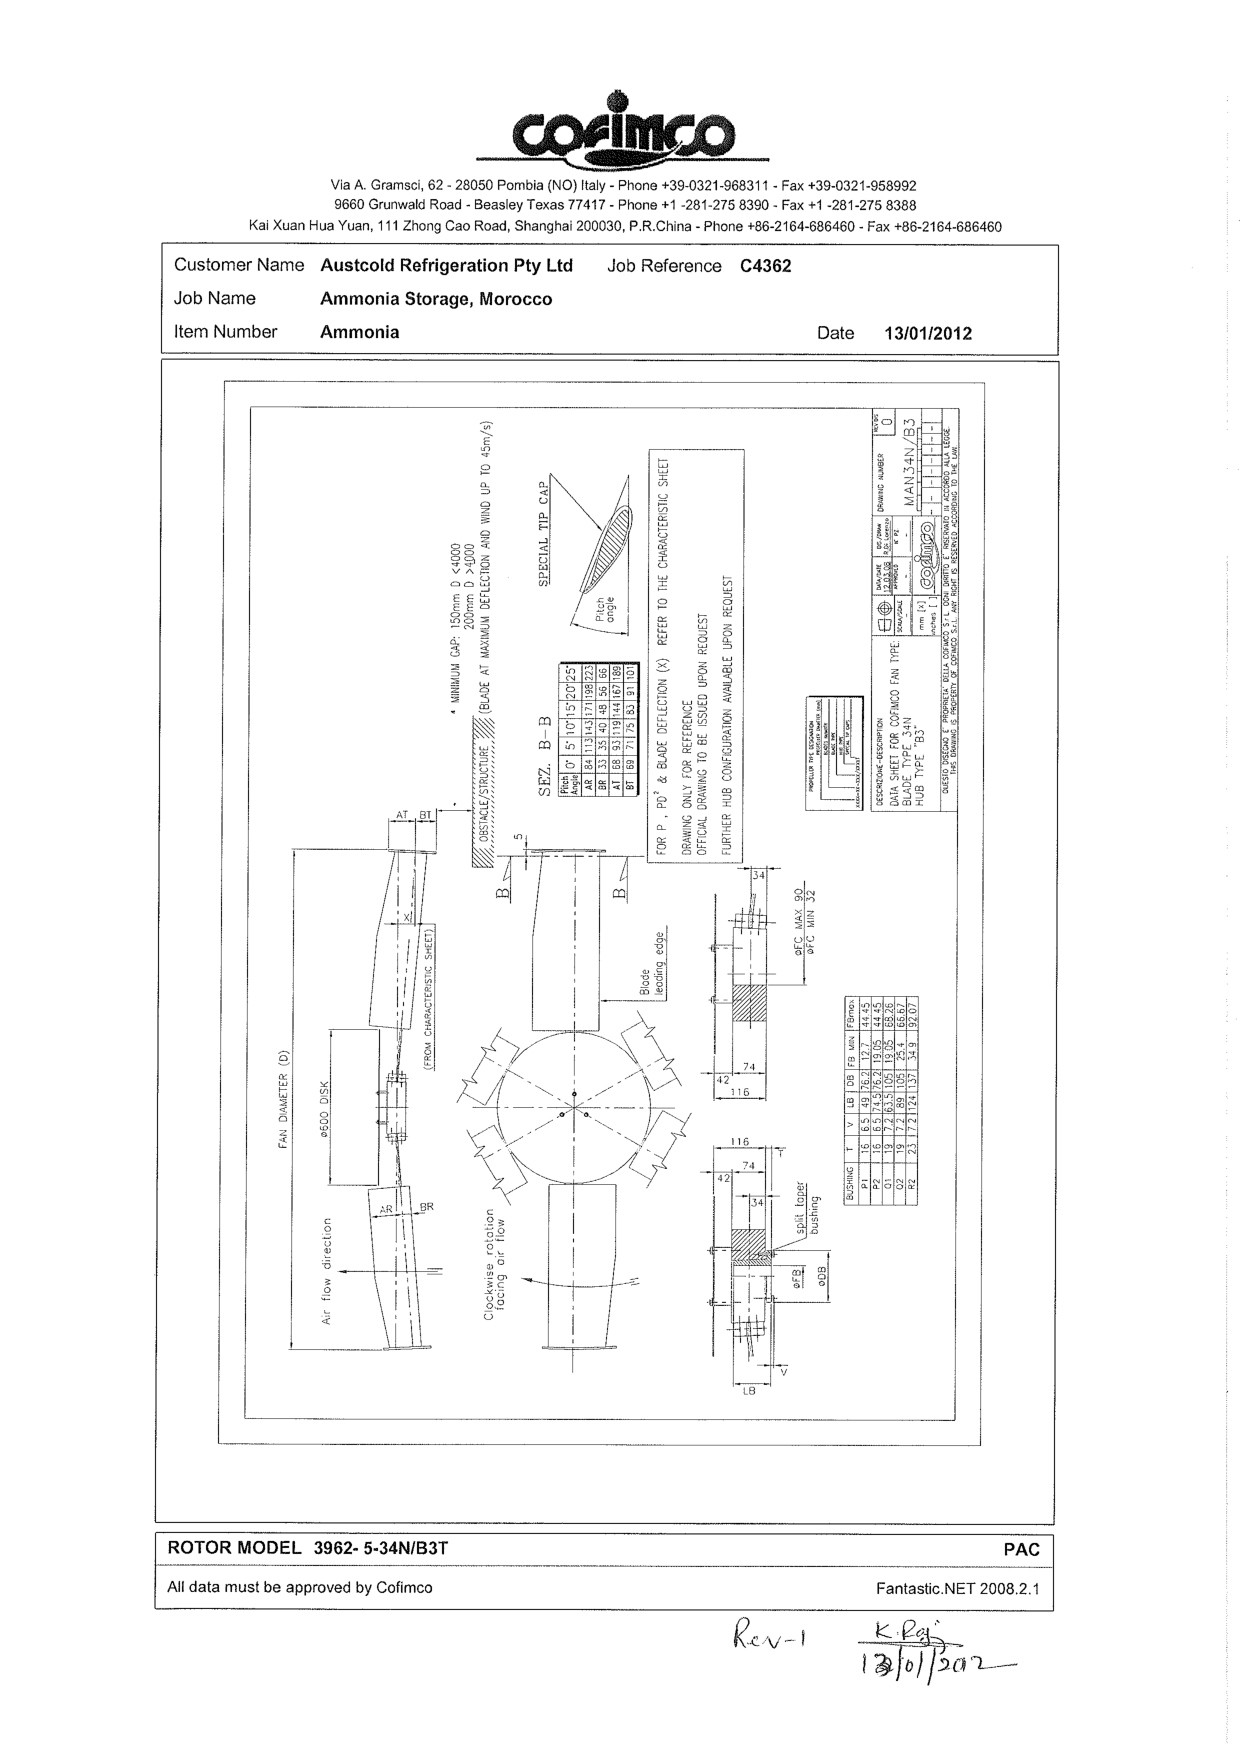

[texte natif vide]


In [4]:
def require_pdf():
    if doc is None:
        raise RuntimeError('PDF non chargé : configurez PDF_PATH et installez PyMuPDF.')

def render_page(page_number, dpi=150):
    require_pdf()
    pix = doc[page_number - 1].get_pixmap(dpi=dpi, alpha=False)
    return pix.pil_image()

def extract_native_text(pdf_path, page_number):
    require_pdf()
    text = doc[page_number - 1].get_text('text')
    return {'text': text, 'page': page_number, 'method': 'native_text'}

def extract_words_with_coordinates(pdf_path, page_number):
    require_pdf()
    words = doc[page_number - 1].get_text('words')
    return pd.DataFrame(words, columns=['x0','y0','x1','y1','word','block','line','word_no'])

def show_selected_pages(show_native_text=True, pages=REPRESENTATIVE_PAGES):
    for item in pages:
        page = item['page']
        print(f"Page {page} | {item.get('type','unknown')} | {item.get('description','')}")
        display(render_page(page))
        if show_native_text:
            print(extract_native_text(PDF_PATH, page)['text'][:1500] or '[texte natif vide]')

show_selected_pages()

## 4. Manual ground truth

Complete this only after visual inspection. Every value must be explicitly visible on the stated page; otherwise use `None`. This small pilot dataset is a decision tool, not a final statistical validation.

In [5]:
GROUND_TRUTH = {
    189: {
        'family': None,
        'asset_name': 'Rotor',
        'reference': 'C4362',
        'power': None,
        'outlier': None,
        'manufacturer': 'CoFimco',
        'asset_diagram': True,
    },

    192: {
        'family': '17',
        'asset_name': 'Three-phase Induction Motor - Squirrel Cage',
        'reference': '175132/2011',
        'power': '30 kW',
        'outlier': None,
        'manufacturer': 'WEG Indústrias S.A.',
        'asset_diagram': False,
    },
}

FIELDS = ['family', 'asset_name', 'reference', 'power', 'outlier', 'manufacturer', 'asset_diagram']
ground_truth_df = pd.DataFrame.from_dict(GROUND_TRUTH, orient='index').rename_axis('page').reset_index()
display(ground_truth_df)
ground_truth_df.to_csv(OUTPUT_DIR / 'ground_truth.csv', index=False)

,page,family,asset_name,reference,power,outlier,manufacturer,asset_diagram
0,189,NaN,Rotor,C4362,NaN,None,CoFimco,True
1,192,17,Three-phase Induction Motor - Squirrel Cage,175132/2011,30 kW,None,WEG Indústrias S.A.,False


## 5. Native extraction and quality check

Native text is the low-cost baseline. OCR is considered only when native text is insufficient or the page is clearly image-based/scanned.

In [6]:
def text_quality(text):
    clean = re.sub(r'\s+', ' ', text or '').strip()
    alnum = sum(c.isalnum() for c in clean)
    return {'characters': len(clean), 'alnum_ratio': alnum / max(len(clean), 1), 'sufficient': len(clean) >= 40 and alnum / max(len(clean), 1) >= 0.35}

def needs_ocr(text, page_image=None):
    quality = text_quality(text)
    return not quality['sufficient']

def native_page_result(page):
    native = extract_native_text(PDF_PATH, page)
    native['quality'] = text_quality(native['text'])
    native['needs_ocr'] = needs_ocr(native['text'])
    return native

[native_page_result(x['page']) for x in REPRESENTATIVE_PAGES]

[{'text': 'INTESCA \n \nOPERATING & MAINTENANCE INSTRUCTION INDEX \n \nSECTION \n1) \nSERVICE CONTACT DETAILS \n1.01 \nContact details \n1.02 \nWarning & material safety data sheets \n1.03 \nSafety precautions \n1.04 \nPackage warranty and support information \n1.05 \nPlant history log \n1.06 \nOil consumption log \n1.07 \nUtilities consumption schedule \n1.08 \nCause & effect chart \n \n \n \n2)  \nDESCRIPTIONS \n2.01 \nControl Philosophy \n \n \n \n3) \nTECHNICAL DATA \n3.01 \nTechnical schedule \n3.02 \nCompressor data sheet \n3.03 \nCompressor motor data sheet \n3.04 \nOil pump data sheet \n3.05 \nOil pump motor data sheet \n3.06 \nOil cooler data sheet  \n3.07 \nOil separator data sheet \n3.08 \nLiquid receiver data sheet \n3.09 \nPurger data sheet \n3.10 \nEconomiser data sheet \n3.11 \nCondenser data sheet \n3.12 \nCondenser fan data sheet \n3.13 \nCondenser fan motor data sheet \n3.14 \nCondenser vibration switch data sheet \n3.15 \nFinal stage oil separator data sheet \n3.16 \

## 6. Rules / Regex — simple baseline

These rules are deliberately short and readable. They are a measurable baseline, not a complete business-rule engine. Change patterns only after observing the actual conventions used in the manual.

In [7]:
POWER_RE = re.compile(
    r'(?i)\b(?:power|motor\s*power|rated\s*power|output|puissance)'
    r'\s*[:=]?\s*(\d+(?:[.,]\d+)?)\s*(kW|MW|W|HP)\b'
)

LABELED_RE = {
    'reference': re.compile(
        r'(?im)^\s*'
        r'(?:tag|reference|ref\.?|equipment\s*no\.?|asset\s*no\.?)'
        r'\s*[:#=]\s*([^\n]+)'
    ),

    'manufacturer': re.compile(
        r'(?im)^\s*'
        r'(?:manufacturer|maker|fabricant)'
        r'\s*[:#=]\s*([^\n]+)'
    ),

    'asset_name': re.compile(
        r'(?im)^\s*'
        r'(?:equipment\s*(?:name|designation)|asset\s*name|designation)'
        r'\s*[:#=]\s*([^\n]+)'
    ),
}

In [8]:
def _first_match(pattern, text, group=1):
    match = pattern.search(text or '')
    return match.group(group).strip() if match else None

# 2. Individual extraction functions
def extract_reference(text):
    return _first_match(LABELED_RE['reference'], text)


def extract_manufacturer(text):
    return _first_match(LABELED_RE['manufacturer'], text)


def extract_asset_name(text):
    return _first_match(LABELED_RE['asset_name'], text)


def extract_power(text):
    match = POWER_RE.search(text or '')

    if not match:
        return {
            'power': None,
            'power_unit': None
        }

    return {
        'power': float(match.group(1).replace(',', '.')),
        'power_unit': match.group(2)
    }

# 3. Fields that cannot currently be reliably extracted
def extract_family(text):
    """
    Family is an i-Sense classification.
    It should not be guessed from the PDF text alone.
    """
    return None


def extract_outlier(text):
    """
    No reliable Outlier pattern has been established yet.
    """
    return None


def extract_asset_diagram(text):
    """
    A text-only extractor cannot reliably determine whether
    a page contains an asset diagram.
    This should be determined from page type / visual analysis.
    """
    return None

# 4. Complete rule-based extraction
def extract_rules(text):
    
    power = extract_power(text)

    values = {
        'family': extract_family(text),
        'asset_name': extract_asset_name(text),
        'reference': extract_reference(text),
        'power': (
            f"{power['power']} {power['power_unit']}"
            if power['power'] is not None
            else None
        ),
        'outlier': extract_outlier(text),
        'manufacturer': extract_manufacturer(text),
        'asset_diagram': extract_asset_diagram(text),
    }

    return {
        'method': 'rules',
        'values': values
    }

In [9]:
extract_rules(extract_native_text(PDF_PATH, REPRESENTATIVE_PAGES[8]['page'])['text'])

{'method': 'rules',
 'values': {'family': None,
  'asset_name': None,
  'reference': None,
  'power': '30.0 kW',
  'outlier': None,
  'manufacturer': None,
  'asset_diagram': None}}

## 7. Table extraction

Attempts are restricted to table or datasheet pages. `pdfplumber` is tried first; Camelot can be enabled manually for structured, vector-based tables.

In [10]:
def extract_tables(pdf_path, page_number):
    result = {'page': page_number, 'method': 'table', 'success': False, 'tables': [], 'message': ''}
    if pdfplumber is None:
        result['message'] = 'pdfplumber indisponible ; extraction de tableaux ignorée.'
        return result
    try:
        with pdfplumber.open(pdf_path) as pdf:
            raw_tables = pdf.pages[page_number - 1].extract_tables()
        result['tables'] = [pd.DataFrame(t[1:], columns=t[0]) if t and len(t) > 1 else pd.DataFrame(t) for t in raw_tables]
        result['success'] = bool(result['tables'])
        result['message'] = f"{len(result['tables'])} tableau(x) détecté(s)"
    except Exception as exc:
        result['message'] = f'Échec table extraction : {exc}'
    return result

def display_tables(table_result):
    print(table_result['message'])
    for i, table in enumerate(table_result['tables']):
        print(f'Tableau {i + 1}')
        display(table)
display_tables(extract_tables(PDF_PATH, REPRESENTATIVE_PAGES[5]['page']))

3 tableau(x) détecté(s)
Tableau 1


,0,1
0,,AUSTCOLD REFRIGERATION Pty. Ltd.\n(A member of...


Tableau 2


,,NaN,DOCUMENT No.\nV-JA255-INT-ME-C-002-087,NaN,DESCRIPTION:\nCAUSE & EFFECT DIAGRAM\nA5114-TDS-30,NaN
0,NaN,NaN,ÉDITION / ISSUE,05,NaN,NaN
1,CLIENTE / CLIENT: MAROC PHOSPHORE,NaN,NaN,PLANTA/PLANT: COMPLEXE JORF LASFAR-MAROC,NaN,NaN
2,PROJET / PROJECT: UNITE DE STOCKAGE ET DISTRIB...,NaN,NaN,NaN,NaN,NaN
3,PROJET N. / JOB : PCAP-205J/206J/10 - 16084,NaN,NaN,NaN,NaN,NaN
4,COMMANDE / P.O. : JA255-INT-ME-C-002,NaN,NaN,ITEM Nº: 255-V-100A/B/C/D,NaN,NaN
5,ÉTAT DU DOCUMENT / STATUS OF DOCUMENT,NaN,NaN,ST,DATE,SIGNATURE
6,POUR INFORMATION / FOR INFORMATION ONLY,NaN,NaN,D,,
7,PAS APROUVÉ\nNOT APPROVED,AVEC DES COMMENTAIRES\nWITH COMMENTS,NaN,C,,
8,APROUVE POUR\nCONSTRUCTION\nAPPROVED FOR\nCONS...,AVEC DES COMMENTAIRES\nWITH COMMENTS,NaN,B,,
9,NaN,PAS COMMENTAIRES\nWITHOUT COMMENTS,NaN,A,,


Tableau 3


,05,07-Mar-2013,Revised as per comments,P.P.,C.V.,M.H
0,04,24-Jan-2013,Revised as per comments,P.P.,C.V.,M.H
1,03,11-Jul-2012,Revised as per comments,P.P.,V.A.,M.H
2,02,05-Jun-2012,Revised as per comments,P.P.,V.A.,M.H
3,01,11-Jan-2012,First issue,P.S.,V.A.,M.H
4,REV.,DATE,DESCRIPTION,ISSUER,CHECKER,APPROVER


## 8. Targeted OCR fallback

A page is sent to OCR only when native text quality fails. If Tesseract or its executable is not configured, the result records a message and the experiment continues.

In [11]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

In [12]:
def ocr_page(page_number, dpi=300, lang='eng'):
    """
    Extract text from a PDF page using Tesseract OCR.
    """

    if pytesseract is None:
        raise RuntimeError(f"Tesseract unavailable: {OCR_ERROR}")

    # Render PDF page internally
    image = render_page(page_number, dpi=dpi)

    # Extract text
    text = pytesseract.image_to_string(
        image,
        lang=lang
    )

    return text

In [13]:
text_page = ocr_page(
    REPRESENTATIVE_PAGES[1]['page'],
    dpi=300,
    lang='eng'
)

print(text_page)

|
\
\
4
\
N
\
\
\
N
\
N
\
\
\
\
b

j
f
j
,

PF A Fe,

| SECTION 1.01




## 9. LLM — difficult cases only

By default, the LLM is not called. The payload contains only the targeted page's text, OCR, and tables. The client implementation is intentionally explicit because it depends on the approved provider and credentials.

In [14]:
page = REPRESENTATIVE_PAGES[8]['page']

native_result = extract_native_text(PDF_PATH, page)
ocr_result = ocr_page(page, dpi=300, lang='eng')
table_result = extract_tables(PDF_PATH, page)

In [15]:
from src.llm.extractor import extract_with_llm

result = extract_with_llm(
    native_result,
    ocr_result,
    table_result
)

c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")
c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")


In [16]:
result

{'method': 'llm',
 'called': True,
 'result': {'family': {'value': None, 'confidence': 0.0, 'page': None},
  'asset_name': {'value': 'Three-phase Induction Motor - Squirrel Cage',
   'confidence': 1.0,
   'page': 1},
  'reference': {'value': 'Nr.: 175132/2011', 'confidence': 1.0, 'page': 1},
  'power': {'value': '30 kW', 'confidence': 1.0, 'page': 1},
  'outlier': {'value': None, 'confidence': 0.0, 'page': None},
  'manufacturer': {'value': 'WEG Indústrias S.A.',
   'confidence': 1.0,
   'page': 1},
  'asset_diagram': {'value': None, 'confidence': 0.0, 'page': None}}}

## 10. Per-page experiment pipeline

Every result remains separated by method. The pipeline does not silently merge outputs: comparison must reveal which method truly works.

In [17]:
def run_page_experiment(pdf_path, page_number):
    native = native_page_result(page_number)
    rules = extract_rules(native['text'])
    table = extract_tables(pdf_path, page_number)
    ocr = ocr_page(page_number)

    llm = extract_with_llm(native, ocr, table)

    return {
        'page': page_number,
        'native_text': native,
        'rules': rules,
        'tables': table,
        'ocr': ocr,
        'llm': llm
    }

In [18]:
EXPERIMENTS = {item['page']: run_page_experiment(PDF_PATH, item['page']) for item in REPRESENTATIVE_PAGES} if doc else {}
print(f'{len(EXPERIMENTS)} page(s) expérimentée(s)')
with open(OUTPUT_DIR / 'raw_experiments.json', 'w', encoding='utf-8') as handle:
    json.dump(EXPERIMENTS, handle, default=str, ensure_ascii=False, indent=2)

c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")
c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")
c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")
c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")
c:\Users\intel\Downloads\industrial-equipment-data-extraction\src\llm\extractor.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  .to_dict("records")


10 page(s) expérimentée(s)


## 11. Ground-truth comparison

Normalisation allows only case, whitespace, and obvious unit-format differences. It does not equate different values such as `15 kW` and `18 kW`.

In [19]:
def normalize_value(value, field=None):
    if value is None or (isinstance(value, float) and np.isnan(value)): return None
    value = re.sub(r'\s+', ' ', str(value).strip()).casefold()
    if field == 'power_unit': return value.replace('kw', 'kw').replace(' ', '')
    if field == 'power':
        number = re.search(r'\d+(?:[.,]\d+)?', value)
        return str(float(number.group().replace(',', '.'))) if number else value
    return value

def compare_to_ground_truth(prediction, truth, method):
    rows = []
    values = prediction.get('values', prediction)
    for field in FIELDS:
        expected, observed = truth.get(field), values.get(field)
        correct = normalize_value(expected, field) == normalize_value(observed, field) if expected is not None else observed is None
        rows.append({'page': truth.get('source_page'), 'field': field, 'ground_truth': expected, 'prediction': observed, 'correct': correct, 'method': method})
    return rows

def method_predictions(experiment):
    native = {'source_page': experiment['page']}  # texte brut : évaluable manuellement, pas une valeur structurée
    return {'rules': experiment['rules'], 'ocr': {}, 'table': {}, 'llm': {}}

comparison_rows = []
for page, truth in GROUND_TRUTH.items():
    if page in EXPERIMENTS:
        for method, prediction in method_predictions(EXPERIMENTS[page]).items():
            comparison_rows.extend(compare_to_ground_truth(prediction, truth, method))
field_comparison = pd.DataFrame(comparison_rows)
display(field_comparison)
field_comparison.to_csv(OUTPUT_DIR / 'field_comparison.csv', index=False)

,page,field,ground_truth,prediction,correct,method
0,None,family,None,NaN,True,rules
1,None,asset_name,Rotor,NaN,False,rules
2,None,reference,C4362,NaN,False,rules
3,None,power,None,NaN,True,rules
4,None,outlier,None,NaN,True,rules
5,None,manufacturer,CoFimco,NaN,False,rules
6,None,asset_diagram,True,NaN,False,rules
7,None,family,None,NaN,True,ocr
8,None,asset_name,Rotor,NaN,False,ocr
9,None,reference,C4362,NaN,False,ocr


## 12. Metrics, errors, and winning method

Metrics are descriptive for a small pilot sample. A method is recommended for a field only when it has produced evaluable, correct values; otherwise the result remains `UNRESOLVED`.

In [20]:
def classify_error(row):
    if pd.isna(row['prediction']) or row['prediction'] is None: return 'MISSING'
    if row['field'] == 'power_unit': return 'WRONG_UNIT'
    return 'WRONG_VALUE'

if not field_comparison.empty:
    field_comparison['status'] = np.where(field_comparison['correct'], 'CORRECT', 'INCORRECT')
    errors = field_comparison.loc[~field_comparison['correct']].copy()
    errors['error_type'] = errors.apply(classify_error, axis=1)
    summary = (field_comparison.assign(found=field_comparison['prediction'].notna())
               .groupby(['field','method'], as_index=False)
               .agg(values_found=('found','sum'), correct=('correct','sum'), total=('correct','size')))
    summary['coverage'] = summary['values_found'] / summary['total']
    summary['accuracy'] = summary['correct'] / summary['total']
    best_method_by_field = (summary.sort_values(['field','accuracy','coverage'], ascending=[True,False,False])
                            .groupby('field', as_index=False).first()[['field','method','accuracy','coverage']]
                            .rename(columns={'method':'best_method'}))
else:
    errors = pd.DataFrame(columns=['page','field','ground_truth','prediction','method','error_type'])
    summary = pd.DataFrame(columns=['field','method','values_found','correct','total','coverage','accuracy'])
    best_method_by_field = pd.DataFrame({'field': FIELDS, 'best_method': 'UNRESOLVED'})
display(summary); display(errors); display(best_method_by_field)
errors.to_csv(OUTPUT_DIR / 'error_analysis.csv', index=False)
summary.to_csv(OUTPUT_DIR / 'method_summary.csv', index=False)

,field,method,values_found,correct,total,coverage,accuracy
0,asset_diagram,llm,0,0,2,0.0,0.0
1,asset_diagram,ocr,0,0,2,0.0,0.0
2,asset_diagram,rules,0,0,2,0.0,0.0
3,asset_diagram,table,0,0,2,0.0,0.0
4,asset_name,llm,0,0,2,0.0,0.0
5,asset_name,ocr,0,0,2,0.0,0.0
6,asset_name,rules,0,0,2,0.0,0.0
7,asset_name,table,0,0,2,0.0,0.0
8,family,llm,0,1,2,0.0,0.5
9,family,ocr,0,1,2,0.0,0.5


,page,field,ground_truth,prediction,correct,method,status,error_type
1,None,asset_name,Rotor,NaN,False,rules,INCORRECT,MISSING
2,None,reference,C4362,NaN,False,rules,INCORRECT,MISSING
5,None,manufacturer,CoFimco,NaN,False,rules,INCORRECT,MISSING
6,None,asset_diagram,True,NaN,False,rules,INCORRECT,MISSING
8,None,asset_name,Rotor,NaN,False,ocr,INCORRECT,MISSING
9,None,reference,C4362,NaN,False,ocr,INCORRECT,MISSING
12,None,manufacturer,CoFimco,NaN,False,ocr,INCORRECT,MISSING
13,None,asset_diagram,True,NaN,False,ocr,INCORRECT,MISSING
15,None,asset_name,Rotor,NaN,False,table,INCORRECT,MISSING
16,None,reference,C4362,NaN,False,table,INCORRECT,MISSING


,field,best_method,accuracy,coverage
0,asset_diagram,llm,0.0,0.0
1,asset_name,llm,0.0,0.0
2,family,llm,0.5,0.0
3,manufacturer,llm,0.0,0.0
4,outlier,llm,1.0,0.0
5,power,rules,1.0,0.5
6,reference,llm,0.0,0.0


## 13. i-Sense mapping — separate layer

Business rules must not live in document extraction. The external file below is a template: example values are not validated rules and must not be used as such.

In [21]:
MAPPING_PATH = OUTPUT_DIR / 'isense_mapping.csv'
if not MAPPING_PATH.exists():
    pd.DataFrame(columns=['normalized_equipment_type','Family','Class','Structure','Group']).to_csv(MAPPING_PATH, index=False)
mapping_df = pd.read_csv(MAPPING_PATH)

def map_to_isense(equipment_type, mapping_df):
    if equipment_type is None or mapping_df.empty: return {'status': 'UNRESOLVED'}
    candidates = mapping_df[mapping_df['normalized_equipment_type'].astype(str).str.casefold() == str(equipment_type).casefold()]
    return candidates.iloc[0].to_dict() if len(candidates) == 1 else {'status': 'UNRESOLVED'}

display(mapping_df)

,normalized_equipment_type,Family,Class,Structure,Group


## 14. Review workflow

A value is accepted only when it is sourced, non-conflicting, and sufficiently reliable. Missing required values, conflicts, low-confidence OCR/LLM output, and unresolved mapping are sent to review.

In [22]:
REQUIRED_FIELDS = {'equipment_name','tag_reference'}
def needs_review(record):
    reasons = []
    if not record.get('source_page'): reasons.append('source page missing')
    for field in REQUIRED_FIELDS:
        if not record.get(field): reasons.append(f'required field missing: {field}')
    if record.get('conflicting_values'): reasons.append('conflicting values')
    if record.get('low_confidence'): reasons.append('low confidence')
    if record.get('mapping_status') == 'UNRESOLVED': reasons.append('i-Sense mapping unresolved')
    return ('REVIEW' if reasons else 'ACCEPT'), reasons

review_queue = []
for page, truth in GROUND_TRUTH.items():
    status, reasons = needs_review(truth)
    review_queue.append({'page': page, 'field': '*', 'value': '', 'status': status, 'reason': '; '.join(reasons)})
review_queue = pd.DataFrame(review_queue)
display(review_queue)
review_queue.to_csv(OUTPUT_DIR / 'review_queue.csv', index=False)

,page,field,value,status,reason
0,189,*,,REVIEW,source page missing; required field missing: t...
1,192,*,,REVIEW,source page missing; required field missing: t...


## 16. Automatic summary and experimental conclusion

This recommendation is a pilot-based hypothesis. It must be confirmed with a broader sample before any deployment.

In [24]:
print('PILOT SUMMARY')
print(f'Pages evaluated: {len(EXPERIMENTS)}')
if not summary.empty:
    for method, group in summary.groupby('method'):
        print(f'{method}: coverage={group.coverage.mean():.0%}, accuracy={group.accuracy.mean():.0%}')
    print('\nBest method by field:')
    display(best_method_by_field)
else:
    print('Complétez GROUND_TRUTH et exécutez les expériences pour obtenir les métriques.')
print('\nRECOMMENDED PILOT ARCHITECTURE')
print('1. Texte PDF natif en première couche')
print('2. Rules/regex pour valeurs structurées validées')
print('3. Table extraction pour pages à tableaux qui réussissent le test')
print('4. OCR seulement si texte natif insuffisant')
print('5. LLM seulement pour cas difficiles et ambigus, sur pages ciblées')
print('6. Mapping métier i-Sense séparé')
print('7. Revue humaine pour données manquantes, conflictuelles ou non sourcées')

# Résultat consolidé minimal exportable (à alimenter à partir de la méthode gagnante validée).
pd.DataFrame([{'page': p, 'native_text_chars': len(e['native_text']['text']), 'ocr_needed': e['native_text']['needs_ocr']} for p,e in EXPERIMENTS.items()]).to_csv(OUTPUT_DIR / 'extraction_results.csv', index=False)

PILOT SUMMARY
Pages evaluated: 10
llm: coverage=0%, accuracy=29%
ocr: coverage=0%, accuracy=29%
rules: coverage=7%, accuracy=36%
table: coverage=0%, accuracy=29%

Best method by field:


,field,best_method,accuracy,coverage
0,asset_diagram,llm,0.0,0.0
1,asset_name,llm,0.0,0.0
2,family,llm,0.5,0.0
3,manufacturer,llm,0.0,0.0
4,outlier,llm,1.0,0.0
5,power,rules,1.0,0.5
6,reference,llm,0.0,0.0



RECOMMENDED PILOT ARCHITECTURE
1. Texte PDF natif en première couche
2. Rules/regex pour valeurs structurées validées
3. Table extraction pour pages à tableaux qui réussissent le test
4. OCR seulement si texte natif insuffisant
5. LLM seulement pour cas difficiles et ambigus, sur pages ciblées
6. Mapping métier i-Sense séparé
7. Revue humaine pour données manquantes, conflictuelles ou non sourcées


## NEXT ACTION

1. Review the representative pages.
2. Fill the ground truth manually.
3. Run the experiments.
4. Review field-level errors.
5. Validate the winning method for each field.
6. Complete the i-Sense mapping table.
7. Only then design the full extraction architecture.